# Adaptive TCF for Wright $\omega$ #

This Jupyter notebook contains Maple code (licensed by the MIT license below) to explore the use of the Adaptive Thiele Continued Fraction method of rational approximation to approximate the Wright $\omega$ function,  on the interval $10^{-4} \le \omega \le 10^3$.

© Robert M. Corless 2026 (MIT Release licence)

Permission is hereby granted, free of charge, to any person obtaining a copy of this software and associated documentation files (the "Software"), to deal in the Software without restriction, including without limitation the rights to use, copy, modify, merge, publish, distribute, sublicense, and/or sell copies of the Software, and to permit persons to whom the Software is furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


In [1]:
# Translation of Oliver Salazar Celis' Matlab code
# from https://github.com/oscelis/tcf/blob/main/tcf.m
# Translation by Robert M Corless July 2026
#
# First Version: TCF with evalhf for speed
#
# CALL:
#   evalhf(evalhftcf(m, f, x, tmp, skip, aa, ss, phi, zz, err, tol, kay, eqtm))
#
# Input:
# m = dimension of input vectors f and x
# f = vector complex(float[8]) of function values
# x = vector complex(float[8]) of interpolation nodes
# tmp = vector complex(float[8]) size m temporary work space
# aa = vector complex(float[8]) of size nmax reciprocal differences on output
# ss = vector complex(float[8]) of size nmax scale factors on output
# ff = vector complex(float[8]) of size nmax chosen function values on output
# zz = vector complex(float[8]) of size nmax 
#             chosen interpolation nodes on output
#
# tol = positive float, usually 1.0e-13
# k  = dimension of aa,ss,ff,zz on output
# eqtm = 1 if scaling is to be done
evalhftcf := proc(m, f, x, tmp, skip, aa, ss, phi, zz, err, tol, kay, eqtm )
  local abstol, alpha, bigf, dt, e, i, j, k, ell, imin, imax, mindist, minf, 
        nmax, normf, skipj, tv ;
  #
  # Hardcoded workspace sizes
  #
  nmax := 250;

  minf := abs(f[1]);
  normf := minf;
  imin := 1;
  imax := 1;
  for i from 2 to m do
    tv := abs(f[i]);
    if tv > normf then
      imax := i;
      normf := tv;
    elif tv < minf then
      imin := i;
      minf := tv;
    end if;
  end do;
  
  abstol := tol*normf;   # Absolute tolerance

    for k to min(nmax,m) do # main loop
        if k=1 then # initialize
            i := imin; #smallest value
            skip[1] := i;
            aa[1] := inv_diff_cfrac(aa,zz,ss,x[i],f[i],0); # ss[1] = 1
        else
            evalhfcfrac(aa,zz,ss,x,tmp,k-1,m);
            # i was found the previous loop: location max diff
            i := imax;
            #adaptive choice
            aa[k] := inv_diff_cfrac(aa,zz,ss,x[i],f[i],k-1); 
            if abs(eqtm-1)<1/2 then # apply equivalence transformation
                alpha := 1/2;
                mindist := evalf( exp(-2*Pi*sqrt(k)/sqrt(alpha)) );
                e := 1/(abs(aa[k-1]*aa[k])+mindist);
                ss[k-1] := 2^round(log(e)/log(2)); # pow2(1,round(log2(e)));
            end if;
            aa[k] := aa[k]*ss[k-1];
        end if;
        zz[k] := x[i]; # store chosen node
        phi[k] := f[i];
        #f[i] := Float(undefined); # remove from consideration
        # We should not have to.  The interpolant should match this
        # now, so it will automatically not be the maximum error.
        evalhfcfrac(aa,zz,ss,x,tmp, k, m);
        bigf := -1;
        for j to m do
          skipj := 0;
          for ell to k-1 do
            if skip[ell]=j then 
              skipj := 1;
            end if;
          end do;
          if skipj = 0 then
            tv := abs(tmp[j]-f[j]);
            if tv>bigf then
              bigf := tv;
              imax := j;
            end if;
          end if;
        end do;
        skip[k] := imax;
        err[k] := bigf;
        if err[k] <= abstol then
          kay[1] := k;
          break
        end if;
    end do;
end proc:
# up to the user to construct R from aa, ss, and zz

kilobytes used=744, alloc=5168, time=0.27

proc (m, f, x, tmp, skip, aa, ss, phi, zz, err, tol, kay, eqtm) local abstol, alpha, bigf, dt, e, i, j, k, ell, imin, imax, mindist, minf, nmax, normf, skipj, tv; nmax := 250; minf := abs(f[1]); normf := minf; imin := 1; imax := 1; for i from 2 to m do tv := abs(f[i]); if normf < tv then imax := i; normf := tv elif tv < minf then imin := i; minf := tv end if end do; abstol := tol*normf; for k to min(nmax,m) do if k = 1 then i := imin; skip[1] := i; aa[1] := inv_diff_cfrac(aa,zz,ss,x[i],f[i],0) else evalhfcfrac(aa,zz,ss,x,tmp,k-1,m); i := imax; aa[k] := inv_diff_cfrac(aa,zz,ss,x[i],f[i],k-1); if abs(eqtm-1) < 1/2 then alpha := 1/2; mindist := evalf(exp(-2*Pi*sqrt(k)/sqrt(alpha))); e := 1/(abs(aa[k-1]*aa[k])+mindist); ss[k-1] := 2^round(log(e)/log(2)) end if; aa[k] := aa[k]*ss[k-1] end if; zz[k] := x[i]; phi[k] := f[i]; evalhfcfrac(aa,zz,ss,x,tmp,k,m); bigf := -1; for j to m do skipj := 0; for ell to k-1 do if skip[ell] = j then skipj := 1 end if end do; if skipj = 0 then tv := abs(tmp[j

In [2]:
# FUNCTION NAME:
#   evalhfcfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + ss1*(x-zz1)/aa2+...
#  INPUT:
#   aa - (vector double) inverse differences
#   zz - (vector double) associated locations used
#   ss - (vector double) associated scalings used
#   x  - (vector double) location where to evaluate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by tcf
#  See also tcf, prz_cfrac
# evalhf version: output is in r
evalhfcfrac := proc(aa, zz, ss, x, r, k, m)
  local dr, dt, i, j, tmp;
  # backward evaluation of continued fraction aa1 + (x-zz1)/aa2+...
  #m := numelems(x), also r;
  #k := numelems(aa);
  if k>1 then
      for i from k by -1 to 2 do
          for j to m do
            r[j] :=  (x[j]*ss[i-1]-ss[i-1]*zz[i-1])/(aa[i]+r[j]);
          end do;
      end do;
  end if;
  # add constant; does not change derivative
  for j to m do
    r[j] := aa[1]+r[j];
  end do;
end proc:


# FUNCTION NAME:
#   inv_diff_cfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + (x-zz1)/aa2+...
#  INPUT:
#   aa - (vector float) inverse differences
#   zz - (vector float) associated locations used
#   zz - (vector float) associated scalings used
#   x  - (float) location where to evaluate
#   f  - (float) value of f(x) to interpolate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by cfrac_interpolate
#  See also tcf, prz_cfrac
inv_diff_cfrac := proc(aa,zz,ss,x,f,k)
  local i, r;
# backward evaluation of continued fraction for inverse differences
    r := f;
    if k>0 then
        for i to k do
            r := (ss[i]*x-ss[i]*zz[i])/(r-aa[i]);
        end do;
    end if;
    return r;
end proc:

We need the following versions for use in pzr_cfrac (not adapted as much for evalhf).  Could rewrite pzr_cfrac to use the above versions, instead, but I have not done so.

In [3]:

# FUNCTION NAME:
#   evalcfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + ss1*(x-zz1)/aa2+...
#  INPUT:
#   aa - (vector double) inverse differences
#   zz - (vector double) associated locations used
#   ss - (vector double) associated scalings used
#   x  - (vector double) location where to evaluate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by tcf
#  See also tcf, prz_cfrac

evalcfrac_unrolled := proc(aa::Vector,
                           zz::Vector,
                           ss::Vector, 
                           x::Vector, 
                           {k::posint := numelems(aa)},
                           {m::posint := numelems(x)})
  local dr, dt, i, j, r, tmp;
  # backward evaluation of continued fraction aa1 + (x-zz1)/aa2+...
  #m := numelems(x), also r;
  #k := numelems(aa);
  r := Vector(m,0);
  if k>1 then
      for i from k by -1 to 2 do
          for j to m do
            r[j] :=  (x[j]*ss[i-1]-ss[i-1]*zz[i-1])/(aa[i]+r[j]);
          end do;
      end do;
  end if;
  # add constant; does not change derivative
  for j to m do
    r[j] := aa[1]+r[j];
  end do;
  return r;
end proc:


# FUNCTION NAME:
#   inv_diff_cfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + (x-zz1)/aa2+...
#  INPUT:
#   aa - (vector float) inverse differences
#   zz - (vector float) associated locations used
#   zz - (vector float) associated scalings used
#   x  - (float) location where to evaluate
#   f  - (float) value of f(x) to interpolate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by cfrac_interpolate
#  See also tcf, prz_cfrac
inv_diff_cfrac_unrolled := proc(aa::Vector(datatype=float),
   zz::Vector(datatype=float),
   ss::Vector(datatype=float),x,f,k)
  local i, r;
# backward evaluation of continued fraction for inverse differences
    r := f;
    if k>0 then
        for i to k do
            r := (ss[i]*x-ss[i]*zz[i])/(r-aa[i]);
        end do;
    end if;
    return r;
end proc:


In [4]:
# Gemini's translation of prz_cfrac, with many errors fixed 
# and the logic of k changed
# 
# Note that it returns poles, zeros, residues
# so I have changed the name to pzr_cfrac
pzr_cfrac := proc(aa::Vector, zz::Vector, ss::Vector, 
                 {bal::truefalse := true}, 
                 {k::posint := numelems(aa)})
    local C, Dp, dt, pol, zer, res, Dl, Dr, Dz, iter, T1, T2, dz, pz, i, j, vz;
    uses LinearAlgebra;

  if Digits > 15 then
    dt := complex(float);
  else
    dt := complex(float[8]);
  end if;

    # --- POLES CALCULATION ---
    # C is a (k-1) x (k-1) matrix with superdiagonal -ss[2..(k-1)]
    C := Matrix(k-1, k-1, datatype=dt, 0 );
    for i from 1 to k-2 do
        C[i, i+1] := -ss[i+1];
    end do;

    # Dp is a (k-1) x (k-1) tridiagonal-like matrix
    Dp := Matrix(k-1, k-1, datatype=dt, 0);
    for i from 1 to k-1 do
        Dp[i, i] := aa[i+1]; # main diagonal aa[2..k]
    end do;
    for i from 1 to k-2 do
        Dp[i, i+1] := -ss[i+1] * zz[i+1]; # superdiagonal
        Dp[i+1, i] := -1;                  # subdiagonal
    end do;

    if not bal then
        pol := Eigenvalues(Dp, C);
    else
        # Call the previously defined baleig procedure
        Dl, Dr, iter := baleig(Dp, C, 5);
        T1 := DiagonalMatrix(Vector(k-1, i -> 1.0 / Dl[i]));
        T2 := DiagonalMatrix(Dr);
        pol := Eigenvalues(T1 . Dp . T2, T1 . C . T2);
    end if;
    # Filter out infinity values if any are present
    pol := Vector( select( t->type(t,complex(numeric)), convert(pol,list) ) );


    # --- ZEROS CALCULATION ---
    # C is a k x k matrix with superdiagonal -ss[1..(k-1)]
    C := Matrix(k, k, datatype=complex(float), 0);
    for i from 1 to k-1 do
        C[i, i+1] := -ss[i];
    end do;

    # Dz is a k x k matrix
    Dz := Matrix(k, k, datatype=dt, 0);
    for i from 1 to k do
        Dz[i, i] := aa[i]; # main diagonal aa[1..k]
    end do;
    for i from 1 to k-1 do
        Dz[i, i+1] := -ss[i] * zz[i]; # superdiagonal
        Dz[i+1, i] := -1;              # subdiagonal
    end do;

    if not bal then
        zer := Eigenvalues(Dz, C);
    else
        Dl, Dr, iter := baleig(Dz, C, 5);
        T1 := DiagonalMatrix(Vector(k, i -> 1.0 / Dl[i]));
        T2 := DiagonalMatrix(Dr);
        zer := Eigenvalues(T1 . Dz . T2, T1 . C . T2);
    end if;
    zer := Vector( select( t->type(t,complex(numeric)), convert(zer,list) ) );


    # --- RESIDUES CALCULATION ---
    res := Vector(Dimension(pol), datatype=dt, 0); # undefined behaves like NaN
    
    # 4-point complex circle step for approximate limit computation
    dz := Vector(4, j -> Float(1,-2-floor(Digits/4)) * exp(2.0 * I * Pi * j / 4.0));
    
    # Loop over each pole to calculate the residue
    for i from 1 to Dimension(pol) do
        pz := Vector(4, j -> pol[i] + dz[j]);
        
        # Evaluate the continued fraction at the 4 points
        vz := evalcfrac_unrolled(aa,zz,ss,pz);
        res[i] := 0;
        for j from 1 to 4 do
            res[i] := res[i] + vz[j] * dz[j];
        end do;
        res[i] := res[i] / 4.0;
    end do;

    return pol, zer, res;
end proc:

# Gemini's version of baleig, fixed up manually
baleig := proc(A::Matrix, B::Matrix, max_iter::integer)
    local n, Dl, Dr, dt, M, iter, i, j, emax, emin, d, e;
    uses LinearAlgebra;

  if Digits > 15 then
    dt := complex(float);
  else
    dt := complex(float[8]);
  end if;

    n := RowDimension(A);
    
    # Initialize scaling vectors as row vectors of ones
    Dl := Vector[row](n, datatype=dt, 1);
    Dr := Vector[row](n, datatype=dt, 1);
    
    # M = abs(A)^2 + abs(B)^2 element-wise
    M := Matrix(n, n, datatype=dt, (i,j) -> abs(A[i,j])^2 + abs(B[i,j])^2);

    for iter from 1 to max_iter do
        emax := 0;
        emin := 0;
        
        # Row scaling
        for i from 1 to n do
            # Compute row sum
            d := add(M[i,j],j=1..n);
            
            if d = 0 then
                e := 0;
            else
                e := -round(log[2](abs(d)) / 2);
            end if;
            
            # Scale the row of M by 2^(2*e)
            for j to n do
              M[i,j] := M[i,j]*2^(2*e);
            end do;
            
            # Update Dl
            Dl[i] := Dl[i] * 2^(-e);
            
            # Update bounds
            if e > emax then emax := e; end if;
            if e < emin then emin := e; end if;
        end do;
        
        # Column scaling
        for i from 1 to n do
            # Compute column sum
            d := add(M[j, i], j=1..n);
            
            if d = 0 then
                e := 0;
            else
                e := -round(log[2](abs(d)) / 2);
            end if;
            
            # Scale the column of M by 2^(2*e)
            for j to n do
              M[j, i] := M[j,i] * 2^(2*e);
            end do;
            
            # Update Dr
            Dr[i] := Dr[i] * 2^e;
            
            # Update bounds
            if e > emax then emax := e; end if;
            if e < emin then emin := e; end if;
        end do;
        
        # Stop if norms are all between 1/2 and 2
        if emax <= emin + 2 then
            break;
        end if;
    end do;

    # Return multiple values as a sequence
    return Dl, Dr, iter;
end proc:


kilobytes used=3559, alloc=9776, time=0.67

Second version of TCF code: this one can be compiled using the Maple compiler.  Unfortunately this means it is restricted to vectors of real data on input, not complex(float[8]) data as was wishfully stated in the documentation.

In [5]:
# m = dimension of input vectors f and x
# f = vector complex(float[8]) of function values
# x = vector complex(float[8]) of interpolation nodes
# tmp = vector complex(float[8]) size m temporary work space
# aa = vector complex(float[8]) of size nmax reciprocal differences on output
# ss = vector complex(float[8]) of size nmax scale factors on output
# ff = vector complex(float[8]) of size nmax chosen function values on output
# zz = vector complex(float[8]) of size nmax 
#             chosen interpolation nodes on output
#
# tol = positive float, usually 1.0e-13
# k  = dimension of aa,ss,ff,zz on output
# eqtm = 1 if scaling is to be done
tcf_toc := proc(m::integer[4], f::Vector(datatype=float[8]), 
                               x::Vector(datatype=float[8]), 
                   tmp::Vector(datatype=float[8]), 
                   skip::Vector(datatype=float[8]),
                   aa::Vector(datatype=float[8]), 
                   ss::Vector(datatype=float[8]), 
                   phi::Vector(datatype=float[8]), 
                   zz::Vector(datatype=float[8]), 
                   err::Vector(datatype=float[8]), 
                   tol::float[8], 
                   kay::Vector(1,datatype=float[8]), 
                   eqtm::integer[4] )
  local abstol, alpha, bigf, dt, e, i, j, k, ell, imin, imax, mindist, minf, 
        nmax, normf, skipj, tv ;
  #
  # Hardcoded workspace sizes
  #
  nmax := 250;

  minf := abs(f[1]);
  normf := minf;
  imin := 1;
  imax := 1;
  for i from 2 to m do
    tv := abs(f[i]);
    if tv > normf then
      imax := i;
      normf := tv;
    elif tv < minf then
      imin := i;
      minf := tv;
    end if;
  end do;
  
  abstol := tol*normf;   # Absolute tolerance

    for k to min(nmax,m) do # main loop
        if k=1 then # initialize
            i := imin; #smallest value
            skip[1] := i;
            aa[1] := f[i]; # ss[1] = 1
            # find imax for next step
            bigf := -1.0;
            for j to m do
              tv := abs(f[j]-aa[1]); # constant approx
              if j<>i and tv < bigf then
                imax := j;
                bigf := tv;
              end if;
            end do;
        else
          # i was found the previous loop: location max diff
          i := imax;
          #adaptive choice
          # inline aa[k] := inv_diff_cfrac_compiled(aa,zz,ss,x[i],f[i],k-1); 
          tv := f[i];
          for j to k-1 do
            tv := (ss[j]*x[i]-ss[j]*zz[j])/(tv-aa[j]);
          end do;
          aa[k] := tv;
          if abs(eqtm-1)<1/2 then # apply equivalence transformation
            alpha := 1/2;
            mindist := evalf( exp(-2*Pi*sqrt(k)/sqrt(alpha)) );
            e := 1/(abs(aa[k-1]*aa[k])+mindist);
            ss[k-1] := exp(log(2)*round(log(e)/log(2))); # pow2(1,round(log2(e)));
          end if;
          aa[k] := aa[k]*ss[k-1];
        end if;
        zz[k] := x[i]; # store chosen node
        phi[k] := f[i];
        #f[i] := Float(undefined); # remove from consideration
        # We should not have to.  The interpolant should match this
        # now, so it will automatically not be the maximum error.
        # However, it seems we must: hence the "skip" kludge below
        # which potentially costs us an extra factor of nmax in 
        # work.  Actually k^2 where k is the final size of aa.
        # 
        # inline evalhfcfrac_compiled(aa,zz,ss,x,tmp, k, m);
        # Initialize
        for j to m do
          tmp[j] := 0.0;
        end do;
        # main body of continued fraction
        for ell from k by -1 to 2 do
          for j to m do
            tmp[j] :=  (x[j]*ss[ell-1]-ss[ell-1]*zz[ell-1])/(aa[ell]+tmp[j]);
          end do;
        end do;
        # constant term of continued fraction
        for j to m do
          tmp[j] := aa[1]+tmp[j];
        end do;

        bigf := -1;
        for j to m do
          # check if node j already processed
          # and is recorded in skip array
          # in 1 <= ell <= k-1
          skipj := 0;
          for ell to k-1 do
            if skip[ell]=j then 
              skipj := 1;
            end if;
          end do;
          # If j is not to be skipped, then
          # check if max difference occurs
          # at j
          if skipj = 0 then
            tv := abs(tmp[j]-f[j]);
            if tv>bigf then
              bigf := tv;
              imax := j;
            end if;
          end if;
        end do;
        skip[k] := imax;
        err[k] := bigf;
        if err[k] <= abstol then
          kay[1] := k;
          break
        end if;
    end do;
end proc:
# up to the user to construct R from aa, ss, and zz

# FUNCTION NAME:
#   evalhfcfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + ss1*(x-zz1)/aa2+...
#  INPUT:
#   aa - (vector double) inverse differences
#   zz - (vector double) associated locations used
#   ss - (vector double) associated scalings used
#   x  - (vector double) location where to evaluate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by tcf
#  See also tcf, prz_cfrac
# evalhf version: output is in r
evalcfrac_toc := proc(aa::Vector(datatype=float[8]), zz::Vector(datatype=float[8]),
                      ss::Vector(datatype=float[8]), x::Vector(datatype=float[8]),
                      r::Vector(datatype=float[8]), k, m)
  local dr, dt, i, j, tmp;
  # backward evaluation of continued fraction aa1 + (x-zz1)/aa2+...
  #m := numelems(x), also r;
  #k := numelems(aa);
  for j to m do
    r[j] := 0;
  end do;
  if k>1 then
      for i from k by -1 to 2 do
          for j to m do
            r[j] :=  (x[j]*ss[i-1]-ss[i-1]*zz[i-1])/(aa[i]+r[j]);
          end do;
      end do;
  end if;
  # add constant; does not change derivative
  for j to m do
    r[j] := aa[1]+r[j];
  end do;
end proc:


# FUNCTION NAME:
#   inv_diff_cfrac
#  DESCRIPTION:
#   Backward evaluation of a continued fraction
#       aa1 + (x-zz1)/aa2+...
#  INPUT:
#   aa - (vector float) inverse differences
#   zz - (vector float) associated locations used
#   zz - (vector float) associated scalings used
#   x  - (float) location where to evaluate
#   f  - (float) value of f(x) to interpolate
#  OUTPUT:
#   r - evaluation of continued fraction at x
#  ASSUMPTIONS AND LIMITATIONS:
#   aa, zz and ss are generated by cfrac_interpolate
#  See also tcf, prz_cfrac
inv_diff_cfrac_toc := proc(aa::Vector(datatype=float[8]),
   zz::Vector(datatype=float[8]),
   ss::Vector(datatype=float[8]),x,f,k)
  local i, r;
# backward evaluation of continued fraction for inverse differences
    r := f;
    if k>0 then
        for i to k do
            r := (ss[i]*x-ss[i]*zz[i])/(r-aa[i]);
        end do;
    end if;
    return r;
end proc:


In [6]:
evalcfrac_compiled := Compiler:-Compile(evalcfrac_toc);

kilobytes used=4543, alloc=13872, time=0.92

proc () options call_external, define_external(maple_compiled_mbe8610e14a30a466c7da57ac2136e0dc,MAPLE,LIB = "C:\\Users\\rcorl\\AppData\\Local\\Temp\\rcorl-17924\\maple_compiled_mbe8610e14a30a466c7da57ac2136e0dcyYxVbxdp.dll"); call_external(0,140723987945328,true,false,false,_passed) end proc

In [7]:
tcf := Compiler:-Compile(tcf_toc);

proc () options call_external, define_external(maple_compiled_m13ac2f15b66cd9f15eae1e43a5ffc4f5,MAPLE,LIB = "C:\\Users\\rcorl\\AppData\\Local\\Temp\\rcorl-17924\\maple_compiled_m13ac2f15b66cd9f15eae1e43a5ffc4f5h9bgQJGw.dll"); call_external(0,140723797697216,true,false,false,_passed) end proc

In [8]:
Digits := 15:
nsamples := 233:
L := -4.0:  U := 3.0:
rfloat := (i->L+(U-L)*(i-1)/(nsamples-1)):
dt := float[8]:
wvals := Vector( nsamples, datatype=dt, i->10^(rfloat(i))):
Z := Vector( nsamples, datatype=dt, i->wvals[i]+ln(wvals[i]) ):
F := Vector( nsamples, datatype=dt, i->wvals[i] ):
tmp := Vector(nsamples, datatype=dt):
skip := Vector(nsamples, datatype=dt):
nmax := 250: # make sure it's the same in evalhfcfrac and evalhftcf
aa := Vector(nmax,datatype=dt):
ss := Vector(nmax,datatype=dt,1):
zz := Vector(nmax,datatype=dt):
phi := Vector(nmax,datatype=dt):
err := Vector(nmax,datatype=dt):
tol := Float(1,-13)/8.0:
k := Vector(1,datatype=dt);
eqtm := 1:

                                   k := [0.]

In [9]:
st := time():
tcf( nsamples, F, Z, tmp, skip, aa, ss, phi, zz, err, tol, k, eqtm ):
time_taken := time()-st;

$$ 0.031$$

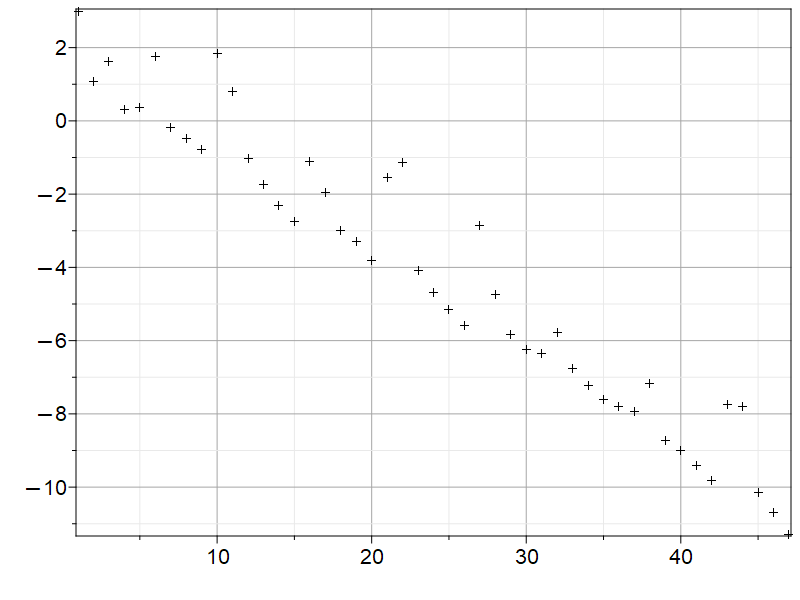

In [10]:
last := round(k[1]):
plot( [seq(j,j=1..last)],
      [seq(log[10](abs(err[j])),j=1..last)] , 
 style=point, symbol=cross, gridlines );

In [11]:
last;

$$47$$

In [12]:
evalf[7](convert(zz[1..last],list));

| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-9.210240|1006.908|66.23047|541.3989|3.006211|-5.803078|2.191572|-7.889950|20.66103|-2.685229|8.628945|-4.755437|181.2426|818.5623|-.3563487|-8.723856|-3.268305|36.73514|292.0068|13.32626|-1.443171|30.27462|1.059997|-6.986231|112.9482|939.7222|-4.052133|11.06068|-3.768760|5.206412|411.2878|-9.001794|9.770116|-2.004376|86.40275|665.6125|.2919694|-6.499331|.6577507|222.2530|-8.306924|50.88508|-.9257633|6.719785|-7.264353|877.0411|24.99034|


AAA chose instead these 23 nodes, in this order:

In [13]:
aa[1..last];

In [14]:
err[1..last];

In [15]:
aaw := aa[1..last]:
ssw := ss[1..last]:
zzw := zz[1..last]:
phiw := phi[1..last];
ntest := 10*nsamples:
wtest := Vector(ntest, datatype=float[8], i->10^(L+(i-1)*(U-L)/(ntest-1))):
xtest := Vector(ntest, datatype=float[8], i->wtest[i]+ln(wtest[i])):
tmp := Vector(ntest, datatype=float[8]):
CodeTools:-Usage( evalcfrac_compiled( aaw, zzw, ssw, xtest, tmp, last, ntest ) ):

memory used=1.23KiB, alloc change=0 bytes, cpu time=0ns, real time=3.00ms, gc time=0ns

kilobytes used=12206, alloc=14384, time=1.72

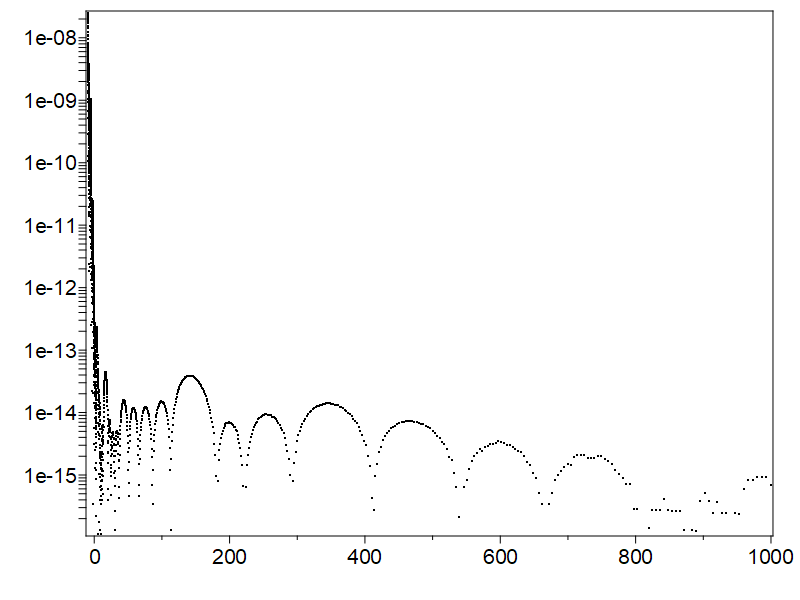

In [16]:
abserr := tmp-wtest:
ferr := Vector(ntest, i->(tmp[i] - wtest[i])/wtest[i]):
plots[logplot]( xtest, abs(ferr), style=point, symbol=point );

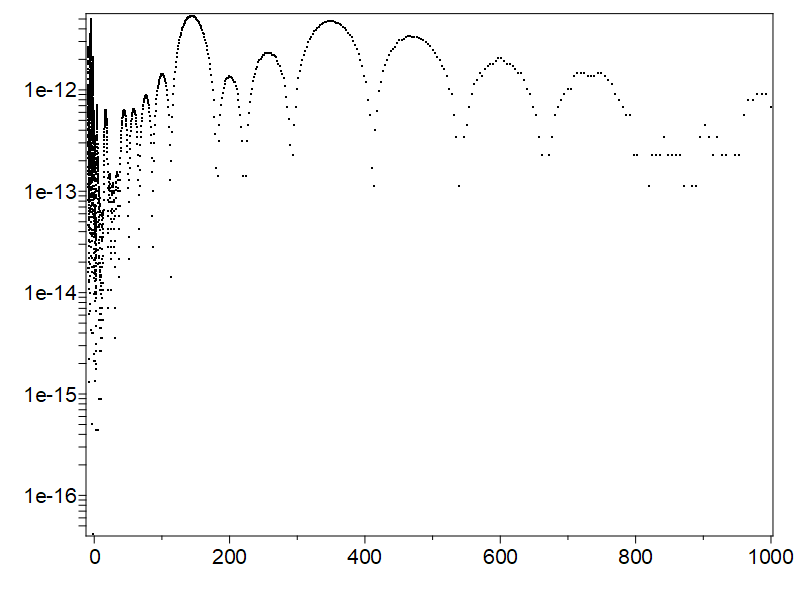

In [17]:
plots[logplot](xtest, abs(abserr), style=point, symbol=point);

In [18]:
(pol,zer,res) := CodeTools:-Usage( pzr_cfrac( aaw, zzw, ssw ) ):

memory used=12.32MiB, alloc change=0 bytes, cpu time=437.00ms, real time=172.00ms, gc time=0ns

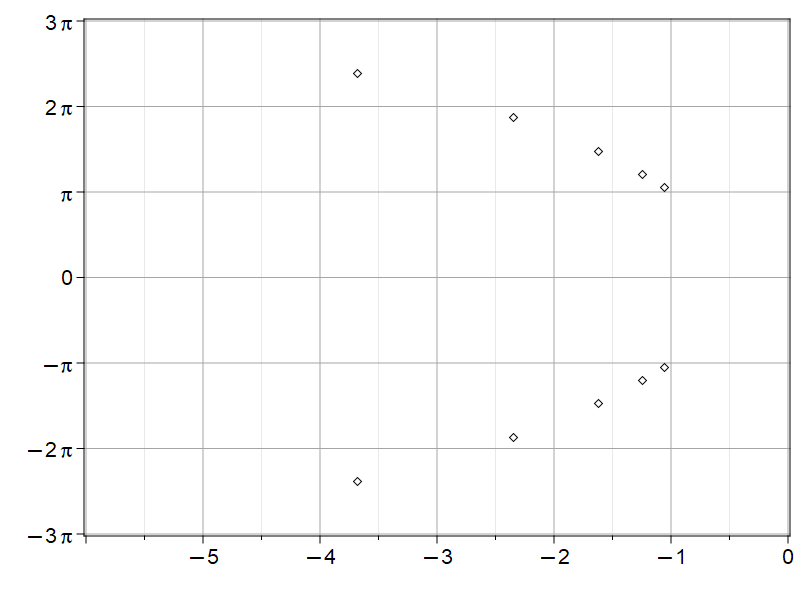

In [19]:
plots[complexplot]( convert(pol,list), style=point, view=[-6..0,-3*Pi..3*Pi], tickmarks=[default,spacing(Pi)], gridlines )

In [20]:
evalf[4](convert(pol,list));

| | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|.2678e9-.1110e-11*I|-3173.-.3513e-10*I|-998.8-.8918e-9*I|-412.9-.1689e-7*I|-186.7+.1131e-7*I|-84.53-.1587e-8*I|-26.54-.7752e-13*I|-17.74-10.41*I|-17.74+10.41*I|-10.40-11.04*I|-10.40+11.04*I|-6.100-9.416*I|-3.678-7.506*I|-2.342-5.861*I|-1.621-4.621*I|-1.240-3.781*I|-1.055-3.298*I|-6.100+9.416*I|-3.678+7.506*I|-1.055+3.298*I|-1.240+3.781*I|-1.621+4.621*I|-2.342+5.861*I|


In [21]:
# ClusterComplexRoots.mpl
#
# clusteredList := ClusterComplexRoots( rootList, tolerance=s, MaxOrder=M );
#
# Take a list rootList of complex numbers and cluster them
# according to apparent multiplicity.
#
# This routine is heuristic (the problem is hard) and is intended
# to work only up to the given maximum order (default MaxOrder is 3)
#
# The routine uses distances and a fuzz factor F[m] and only considers
# neighbouring points up to about |r[i]-r[j]| <= F[m]*s^(1/m) to be
# possible candidates for a cluster; it also uses approximate 
# angle symmetry, looking for angles between adjacent roots to be
# approximately 2*Pi/m .
#
# The returned clusteredList will be a list of pairs [r,m] where
# r is the mean of the original cluster of m roots.
# -----------------------------------------------------------------------------
# (c) Robert M. Corless and Leili Rafiee Sevyeri 2020 (MIT Release licence)
#
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
#
# The above copyright notice and this permission notice shall be included in all
# copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
# SOFTWARE.
# -------------------------------------------------------------------------------

ClusterComplexRoots := proc( rootList::list, 
                            {tolerance::numeric := Float(1,2-Digits)}, 
                            {MaxOrder::nonnegint := 3}, $ )
    local anglesequal, 
          c, closeenough, closeNeighbours, clustered, combos, countem, 
          DistanceMatrix, exactangle, finished_combos, Fuzz,
          i, j, k, m, max_radius, mean, 
          n, neighbours, notInAcluster, nroots, 
          phasedifference, phases, phaseorder, 
          r, radius, trialcluster, trialindices, unseen_m;


    # Safety factors for distance computations.
    # They essentially replace the factor m!*B(r)/(D@@m)(f)(r)
    # which connects the root semimetric with the coefficient
    # metric; in this implementation, no account is taken of
    # the problem in this way (but it can be done in a post-
    # processing validation step).
    Fuzz := Array(2..MaxOrder);
    for m from 2 to MaxOrder do
      Fuzz[m] := evalf(2^(1/m));
    od;

    # Process small rootlists
    nroots := numelems( rootList );
    if nroots=0 then
      error "cannot cluster an empty list of roots";
    elif nroots=1 then
      # Return a cluster of 1
      return [[rootList[1],1]];
    end if;

    # nroots>=2 from now on
    # We will need distances between roots
    # -- to identify "close" roots
    # -- to ignore "far" roots
    DistanceMatrix := Matrix( nroots, nroots, 'shape'='symmetric' );
    for i to nroots do
      for j to nroots do
        DistanceMatrix[i,j] := evalf( abs( rootList[i] - rootList[j]) ) ;
      od;
    od;

    # We order neighbours from nearest to farthest
    neighbours := Array(1..nroots);
    for i to nroots do
      neighbours[i] := sort( [seq(DistanceMatrix[i,j],j=1..nroots)], 
                              'output'='permutation');
      # neighbours[i] should be a list of integers such that
      # the nearest root to rootList[i] should be 
      # rootList[neighbours[i][1]] (itself), the next nearest should be
      # rootList[neighbours[i][2]], and so on
    od;

    # Now begin the clustering.  We start with no clustered roots at all.
    clustered := NULL;
    # The notInAcluster roots are, at the start, all of them.
    # This states that we *assume* these are not in any m-cluster
    # for m > MaxOrder.
    notInAcluster := seq(k,k=1..nroots); 
    for m from MaxOrder by -1 to 2 do
      # The sequence "notInAcluster" can shrink inside this loop
      # The list unseen_m tracks which roots we haven't yet
      # considered for any cluster at level m
      unseen_m := [notInAcluster]; # never any duplicates
      notInAcluster := NULL; # means known not to be part of any m-cluster
      # Assert nroots in clustered, notInAcluster,unseen_m +0(i)
      while numelems(unseen_m) >= m do
        # Checking for m-cycles over all elements of unseen_m
        i := unseen_m[1];
        # print("considering root", i, "or", rootList[i], "for cycles of length", m);
        unseen_m := unseen_m[2..numelems(unseen_m)]; # Assert nroots-1 + 1(i)
        # the root under consideration is rootList[i]
        # we try to find an m-cluster with this in it
        # No need to consider roots farther away than 
        # twice the distance to the centre of any m-cluster
        # to this tolerance
        k := nroots;
        while k > 0 and 
              DistanceMatrix[i,neighbours[i][k]] > 2*Fuzz[m]*tolerance^(1/m) do
          k := k-1;
        od;
        closeNeighbours := {seq(neighbours[i][j], j=2..k)}; # might be empty
        closeNeighbours := closeNeighbours intersect convert(unseen_m,set);
        closeNeighbours := convert(closeNeighbours,list);
        # examine all sets of m-1 close neighbours
        n := numelems(closeNeighbours); # <= k-1
        if n>=m-1 then
          # Now look at all possible choices of m-clusters
          # from the set of close neighbours
          combos := Iterator:-Combination( n, m-1 ); # at least 1
          finished_combos := false;
          for c in combos do
            # Iterator:-Combination indexes from 0 but lists index from 1
            trialindices := [i,seq(closeNeighbours[c[k]+1],k=1..m-1)];
            trialcluster := seq( rootList[k], k in trialindices );
            mean := evalf( add( r, r in [trialcluster] )/m );
            # Check the distances
            closeenough := true;
            max_radius := 0;
            for r in trialcluster do
              radius := abs(r-mean);
              max_radius := max( max_radius, radius ); 
              if radius > Fuzz[m]*tolerance^(1/m) then
                closeenough := false;
                break;
              end if;
            od;
            if closeenough then
              # Now check the angles
              # May be nonsense if max_radius=0
              anglesequal := true;
              if max_radius >= Float(1,1-Digits) then
                phases := [seq( argument( trialcluster[k]-mean), k=1..m) ];
                phaseorder := sort( phases, 'output'='permutation' );
                trialcluster := [seq( trialcluster[phaseorder[k]], k=1..m)];
                phases := [seq( phases[phaseorder[k]], k=1..m)];
                # Now check if all the angles are approximately equal
                exactangle := evalf(2*Pi/m);
                for k from 2 to m do
                  phasedifference := phases[k]-phases[k-1];
                  # Heuristic: what constitutes approximately equal angle?
                  if 0.75*exactangle > phasedifference or
                      phasedifference > 1.25*exactangle then
                    anglesequal := false;
                    break; # no need to consider this trial cluster further
                  end if;
                end do; # exit this loop on break for unequal angles
              end if;
              # closeenough is true, remember
              if anglesequal then
                # We have found a cluster of m roots
                clustered := [mean,m,trialcluster],clustered;
                # print([clustered], unseen_m);
                unseen_m := remove( k->member(k,convert(trialindices,set)), 
                                    unseen_m );
                # print("removed",trialindices,"got",unseen_m);
                # Assert nroots + 1(i)
                break; # stop considering rootList[i]
              end if;
            # else Not close enough to be a cluster.
            end if; 
            finished_combos := Rank(combos)=Number(combos);
            # Go look at the other choices of m-1 elements
          end do; # end for c in combos do; exit this loop via break for found cluster
          # stop looking at rootList[i] but keep looking for m-clusters
          if finished_combos then
            # Loop finished without finding a cluster
            notInAcluster := i,notInAcluster;
            # else We did find a cluster and have seen i
          end if;
          # print(m,"unseen_m",unseen_m);
        else
          # Not enough close neighbours to form an m-cycle
          notInAcluster := i, notInAcluster;
        end if;
      end do; # end while unseen_m has more than m elts do
      # Now look at clusters of smaller order
      for k in unseen_m do
        notInAcluster := k,notInAcluster;
      od;
      unseen_m := [];
    end do;
    # Everything left over is a 1-cluster
    notInAcluster := [notInAcluster];
    return [clustered, seq( [rootList[notInAcluster[k]],1], 
                            k=1..numelems(notInAcluster)) ];
  end proc:


In [22]:
cp := ClusterComplexRoots( convert(pol,list), 
'tolerance'=Float(1,-9) );

| | |
|:-:|:-:|
|267756301.884361-1.10981017567086e-012*I|1|
|-3173.30917820762-3.51336213613002e-011*I|1|
|-998.827687790026-8.91822962371339e-010*I|1|
|-412.917251194041-1.68890656122065e-008*I|1|
|-186.673153362074+1.13065314280533e-008*I|1|
|-84.5295157198716-1.58734190454489e-009*I|1|
|-26.5403692807508-7.7524270755689e-014*I|1|
|-17.7405980382955-10.4104707356727*I|1|
|-17.7405980382954+10.4104707356758*I|1|
|-10.404998470196-11.0375036873539*I|1|
|-10.4049984701959+11.0375036873538*I|1|
|-6.10030951801783-9.41600469124914*I|1|
|-3.6779570592562-7.50647520250518*I|1|
|-2.34214960320483-5.86138561471177*I|1|
|-1.6210352297761-4.62128667301589*I|1|
|-1.23986659802603-3.78074948121051*I|1|
|-1.05513364289659-3.298436494636*I|1|
|-6.10030951801782+9.41600469124912*I|1|
|-3.67795705925619+7.50647520250518*I|1|
|-1.05513364289656+3.29843649463598*I|1|
|-1.23986659802559+3.78074948121046*I|1|
|-1.62103522977652+4.62128667301592*I|1|
|-2.34214960320486+5.86138561471176*I|1|


In [23]:
#cp := ClusterComplexRoots( convert(pol,list), 'tolerance'=Float(1,-7) );

In [24]:
numelems(pol);

$$23$$

In [25]:
#lprint( cp[1] );

In [26]:
#cz := ClusterComplexRoots( convert(zer, list), 'tolerance'=Float(1,-7));

In [27]:
#lprint(cz[1]);

In [28]:
numelems(pol);

$$23$$

In [29]:
numelems(zer);

$$23$$

In [30]:
numelems(phiw);

$$47$$

In [31]:
numelems(zzw);

$$47$$

In [32]:
zs := zzw[1..22]; 

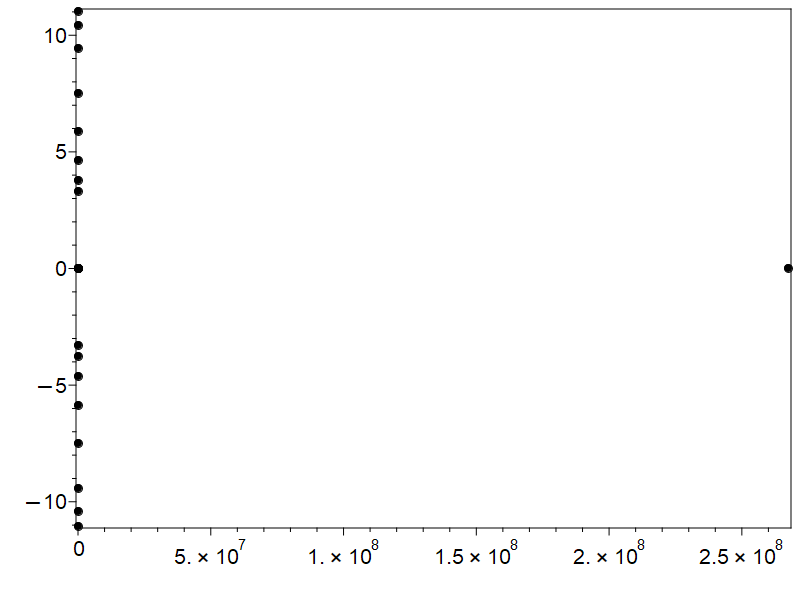

In [33]:
plots[pointplot]( map(Re,pol), map(Im,pol), style=point, 
symbol=solidcircle);

In [34]:
zzw[1], zer[22];

$$- 9.21024037197618206$$,$$- 2.42710603192152430+ 4.49268117740030615 \,\mathrm{I}$$

## Accurate computation of poles, zeros, residues ##

In [35]:
#evalhfcfrac := proc(aa, zz, ss, x, r, k, m)
X := Vector(1,symbol=x):
Rsymb := Vector(1,0):
evalhfcfrac( aaw, zzw, ssw, X, Rsymb, numelems(aaw), 1):

In [36]:
RR := convert( Rsymb[1], rational );

$$\frac{1}{10000}+\frac{8192 x_{1}+\frac{2813918533}{37295}}{\frac{1409184963}{169291}+\frac{\frac{x_{1}}{4096}-\frac{12332573}{50167673}}{-\frac{52149}{369575063}+\frac{\frac{x_{1}}{64}-\frac{11475869}{11089392}}{-\frac{164841188}{20867}+\frac{\frac{x_{1}}{8192}-\frac{9260227}{140118089}}{-\frac{177745}{1495424281}+\frac{x_{1}-\frac{56523239}{18802152}}{-\frac{2338959849}{257974}+\frac{4 x_{1}+\frac{42051635}{1811609}}{\frac{223163}{1759866115}+\frac{\frac{x_{1}}{4}-\frac{5702598}{10408235}}{-\frac{2431691539}{222859}+\frac{\frac{x_{1}}{8}+\frac{6478480}{6568843}}{-\frac{93941}{788204467}+\frac{\frac{x_{1}}{4}-\frac{28995585}{5613581}}{-\frac{1396065154}{127759}+\frac{2 x_{1}+\frac{47200659}{8788946}}{\frac{167023}{1433220995}+\frac{\frac{x_{1}}{2}-\frac{29029217}{6728335}}{-\frac{3130919799}{329246}+\frac{\frac{x_{1}}{32}+\frac{3898107}{26230904}}{-\frac{24323}{205982906}+\frac{\frac{x_{1}}{256}-\frac{11568926}{16340775}}{-\frac{1950940532}{196717}+\frac{\frac{x_{1}}{4096}-\frac{7708199}{38571018}}{-\frac{81869}{1041360853}+\frac{\frac{x_{1}}{8}+\frac{2238052}{50244095}}{-\frac{1023340693}{75085}+\frac{\frac{x_{1}}{4}+\frac{5083875}{2331022}}{\frac{463968}{5247874579}+\frac{\frac{x_{1}}{64}+\frac{4355536}{85290187}}{-\frac{523126979}{53364}+\frac{\frac{x_{1}}{128}-\frac{12674123}{44161743}}{-\frac{116431}{1441236544}+\frac{\frac{x_{1}}{512}-\frac{4630289}{8118674}}{-\frac{2994935334}{214181}+\frac{\frac{x_{1}}{32}-\frac{15201789}{36503651}}{\frac{40700}{581957579}+\frac{x_{1}+\frac{7750781}{5370660}}{-\frac{1221772337}{82240}+\frac{\frac{x_{1}}{16}-\frac{20185961}{10668191}}{-\frac{182165}{2766388457}+\frac{\frac{x_{1}}{16}-\frac{1314832}{19846571}}{-\frac{1629497161}{94336}+\frac{\frac{x_{1}}{16}+\frac{4399817}{10076545}}{-\frac{247588}{3815423789}+\frac{\frac{x_{1}}{256}-\frac{1851726}{4196983}}{-\frac{847817939}{39193}+\frac{\frac{x_{1}}{1024}-\frac{10094812}{11000153}}{-\frac{64803}{1284618148}+\frac{\frac{x_{1}}{2}+\frac{72481510}{35774497}}{-\frac{1449154965}{88489}+\frac{2 x_{1}-\frac{89777462}{4058405}}{-\frac{95297}{2179486188}+\frac{\frac{x_{1}}{8}+\frac{4914361}{10431784}}{-\frac{2339151842}{142021}+\frac{\frac{x_{1}}{64}-\frac{1974725}{24274377}}{-\frac{60190}{1310982247}+\frac{\frac{x_{1}}{512}-\frac{34998077}{43568069}}{-\frac{1161100515}{69961}+\frac{\frac{x_{1}}{16}+\frac{3497293}{6216171}}{-\frac{119084}{1873295733}+\frac{\frac{x_{1}}{4}-\frac{18824270}{7706877}}{-\frac{805129526}{46953}+\frac{\frac{x_{1}}{32}+\frac{2394734}{38232089}}{-\frac{270170}{4532440457}+\frac{\frac{x_{1}}{256}-\frac{21204059}{62824839}}{-\frac{754957790}{55869}+\frac{\frac{x_{1}}{1024}-\frac{8619647}{13260747}}{-\frac{67568}{681701221}+\frac{\frac{x_{1}}{2}-\frac{5596192}{38334103}}{\frac{1472471601}{137095}+\frac{4 x_{1}+\frac{17780869}{683950}}{\frac{150722}{1198401291}+\frac{\frac{x_{1}}{64}-\frac{1868583}{181815557}}{-\frac{1739458497}{194183}+\frac{\frac{x_{1}}{256}-\frac{8193427}{9437520}}{-\frac{6530}{58341733}+\frac{\frac{x_{1}}{128}+\frac{2396838}{36932473}}{-\frac{976271833}{79636}+\frac{\frac{x_{1}}{32}-\frac{15202240}{9560203}}{-\frac{31898}{416126053}+\frac{\frac{x_{1}}{8}+\frac{4226141}{36520272}}{\frac{779470929}{66151}+\frac{\frac{x_{1}}{8}-\frac{6212569}{7396152}}{-\frac{15469}{191392141}+\frac{\frac{x_{1}}{64}+\frac{5232952}{46103061}}{-\frac{496675009}{400042}-\frac{57395399 x_{1}}{5943091}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}}$$

In [37]:
argh := normal(RR);

$$-\frac{5048300462948174645057228428597253932706179494674044821362908227074213277495879771183637754192545737439630360240758427627631215598108577270253756242302038079181033367690449648907745722292092732413106764229635354183159003264502035570865856488707841048503428922766984813081259535289512239801231292936737803596571186738691939432453537455406404953366273613751166906098775425365414103533008894512577894241032894235086407797705286859539178426662035311847707332656885574231454874920745821907914710916080578773183749229171769859781961544108878530261113471374352541524961684198695778135500925755430966955852207798992223811076096000000000 x_{1}^{23}+25051196165312065680009831820137507136857463598322860619037948925577252858566935028518487179512235385359898346436320978500063128401537735183710805881108553888291151828481096164997416240873113102090458146117241018953952575520478949589730783146120997356932136662856990524315890193483547040572574790399266117004469005660231475255790056157654220998080834762982873888671953819244889273344512867930003070286981499058604896667548159120812803203215350028668529377858836083301407617840588161314111304835351228180386320502798726177748028746203656434228540267367535727701079194384991901201699996659939387542730730001161553507846239226880000000 x_{1}^{22}+33712354720005980806322311792454789305219930651464111222250721507013673799775092681365876289772200168837789152145054911422760277365105305919842882810006413828710690579327718801791808624818246741998379063496041391250175930580053369925529687238943997992323812267271340208282850926143680078902793205672591240528051168455332790334625618790839698184402453174933744241328963977464542338332717903908611252158575946892490599604758993507960794904100880971204826179273093893793039426152552464697060971721318842012037691842412151137880992879765211778335631140117808525160647519231592347819871681998045563934294139165834023299895179822019488000000 x_{1}^{21}+17167792285359640084439553541910044920926721902913323995775369333388532258008513145496041551802838419853741741265064576666111664255521716527141564667016416727924765330542363112855365068721502637534531381404982262565347306916569917127624091389112023991470736823396936625548562953615114285112036219040531449107096390214788406896080031152454569002923735936507416945157781097453827695192699425901207746269235049156255664866336605461052003590523800320053220658097568060073037546432733119700454646950557128237214540821739030858721676342067914614765700222951466955247567135426033910262163646372421592940458007259848535906933212046843395566800000 x_{1}^{20}+3850376442818478013974670744002476280064870912476620535616513842691168100216957899694095903709067930427178322954613809044080314475708391169271566101013727486070680606522437485850081045845501635198475573423116474681282793466458138298575688311111532208759886254747708643474630410714306428488278281837658062945124146236935378691068165270320490373100556031659443301086601938009969480277477948223371378061895499964200803188493743379398856001025268412291232143337868658780516976387141882240683760217253575883186227290338625257617942626294370447056143992020976057218673270258175605014892188046590608320924210397816209844958131959439297447548150000 x_{1}^{19}+426849724032217162732095494917906195497713697615860130265386413753441428828739037848743135194293466009964916976596492021524215087669885231153132910038761817406582929250615592574184904099587795503249111597944167468895784343450978889948781287135855589719047077720550482639857636906571411233233016437757424797697464161047276269231156367006414656036530335358979945188021126631845601631226687766792974896865570154974555332758110822767332415369420028708993182872323177741701644607834264377747883438138596447804515462753791636755802241212156976978725232981673260545928210955769406511910803780658383610558168112918765683690436737980337732567025933500 x_{1}^{18}+26656296651478912206293471813063812147354504351743239547238588646361070702151249920889607127000808183853246087160471717399084344830178935873521652718084268432002185868276797338169991645634005164910756278981847225255291358732580560076648983045047646439418390368988148704293739622283748311994028257289534250538763495898997489928602574022764213559875049063243286838293785596987152204966947291403438719708417572449692018966041365860704955536125415938532811025094300769260118107085316742344556523897270384809782247402017220588067981097997114552047909269296982321420908473119205625086766637822355047711890462052044258405056753166537878658701232476000 x_{1}^{17}+1073192972440838010561681207768266215067178741970811044488139731617345356359989540677274616300926973341811339399488792666353312675266184610918182008965815337536372765071299496744174774701936351074928075517958557966365858287098764118799818762071814188820192117726179878884533543166775907667600412288458715673963612695496414686115478642931607157963312071603484231724291014537597355159812823230787595956314168706244668961471793822575319998971963517777787763181720893445940574253139076199302627277140194247285515535926620516101918020432043237080812029978272313021099724286741661232036068029279224268831258278207698115179377243261884231036382547087725 x_{1}^{16}+30428922928678021685358841109275212338088249642356511059034979692719727529285674030608376433160956320850947091440906353755931438322921835612466075776209736374019423398767763948274452947570319184072331945556463711505955714847495540019383414605745096263715849375605584065656447982079332238487621242384147307051018328359279761475953632932036568606845770759576483031774694981995009140515964393064405080613818810474181647449073720104107410249115375269110229009332878565960247121500375263468280466010278410716422091650326653799135121950674802597035981217237366785725050628299688054615650839150464615978608329714184617333082196487909835196085087683582195 x_{1}^{15}+643296687579023335650164965284117460530867472770436417898503534180350705694296202063304264231204550547131041738662823649457007030159973584632182435590913983109197275360278753192469623866680855672720362171152310602745999628823386324256407391586760376601891126564132512544738279952552999881262002197365389906629033159023657316785431638157523468445811888289885896119222658169013820594585623459005637791231267840477037425877639900834094374004275993558628685516082215056921126016232176464084569620365783370647279406681972983865992869285993392666684459449417809361866531323752262713890389085802185610952677862222231668640854572071627383675460878022807380 x_{1}^{14}+10535307581898862916653262657980547428365410573264711241265980936689444338556177032248598522127449802511895945330250285257947051486545670604269431652914737303466017763812749117029109937173906510039097354419316933070303049092167936018407809490173226583027703266180771615833866732321639941500636112597570227079793202085549742156007141689136591738867343788047644640875381955491623428459256749883593272560951319736411341671719711635595101564961772366369494979383115625072573132861546445242071156697828427609413950509295395368410123123314157310748823743998874416380891761473471157394024958575360096961452475750872957934434808688188693806173480862087994704 x_{1}^{13}+137234459459430815520779103553547011752432601455955680373905043574329714739767828939561858426379413397352618967193432133798282604699658121207687158485525889487334798877859852734206134218543842273842617817601021944939693103017756413805965804757308396740356454451463289953271755110801826592355494262412827398038763511935150194657261995046540407469618642657673093915644256395123010484855280336471970086370864323468078283460375729864434761126825923212844143356177537999116729142111163221695006151399105919081594535453926742371054456198847976202560794556150358584774085982985665446685956133021434982395318822228618868954940791328750958867626817755056781504 x_{1}^{12}+1448461079281894486535977796837526146772190582862439884599977252363937758238847428306315937488220675833279636405767356075250848749106856268991491963734365373039975055258214708962898994438001360868571110686071912234582834051194859522143368362265452549746034995927087203406133882426561422832058299298079458944183282626285888999534201858336869838543466057593836664783027851420068701339507609258662042706684770260296531719654427113496698291707355609173377156771684062124735974463119693310637951852240333289188584483484366647053966184767658565286619764694190345991392813721036811315642972830052752794450991840332407996248690581604230576873571224047708325888 x_{1}^{11}+12547806509776646292833925180623978285378326472204686476650266251863162055692426012781891130289039049199760192115995454269025776399301182808103865323672450833118330088949213456433443530412698477953455569603856869376074036273236319179535166092149308009752620870832423339879605900691312680129531173459061151465117704420831751187587999028293351699289231923257251924429413420438536722797061286433034944576179552887981544773735554466001172633753072989831365991369826878339325388310612220727795397547302237853553687755627280036736139740654294453208566534156405227351184791351179421355117052632001704339804566001388669592744748564675417903785260598561282740224 x_{1}^{10}+89973297549042624993592424955678054568174537891319607137162912108319607719913253025862581336142929821850449081347969851502982680517740497129533177753453607148697414313730214613817500106264943385947556133743114678072517018836876242940236797871951455587101399140876067336510964741526066455034712921002876816895773600786761457628870385032224111094536471246813954203235170395753001199705630004728153191221932191489786051678454295827644308290877968695281882257306894101570774945567489969176286378943085843645573248978885077642364893071679598508701196435715768725883744563205475794559318995042373304835681672451849423612229906849743811547843430953353582673920 x_{1}^{9}+536477607980529315043541047409529053007875922012699523486848862747465022716599882267494129566644536880023214784989116332077443041558760699474424978977885757322608739209124639909856407389718818896080276420515360913645815906708016724922107596216890415251369824559060461828668879688987930035594175692157073443161672580577777991568950593073342702945134954650590578475940389695243775554433588419775464284918141052691148082669241357201745127636477508634499592458053074390032538328890444780180652175423306488776697809922384173397656317416568330074754963149513786803206244789657008918487441221820049892547016939674379173536719108129100582940635903830728646852608 x_{1}^{8}+2662449616273560658997945445914441258170710315262445819206876534467224568509567693912068695256157933827633280845885852039006111706073463220115865882335578346887263106247618224507136886756808059782119315137103217420712310349918397292472076843444472707365449433393111357827599463263194456957827543650808673113923005366192147615846420031635407464488750421421377043847510575641073358369934290903272809941502343596499285647592596053012451311420502259654360089882624496039771585630184275554523947874908541245345344122209993413448149558112550493590731876802708660062869252477845827318285299427320229889597982095941855386818883151218511785109785476471569258643456 x_{1}^{7}+10963301654707516962955044861542060321800777162807182772920530910721674181651857523589751172382151688022182501780558044827713621879655855077894217929669014457432321981531267797830462262156203554051783844047740408920833916974819167757319194251303591663487310492468696515917680635723005707548507353578232547862073088482182694924234807676451630537019955940502560278888228437068629794051873310408642357475457190462248998283192459178758759646198374041701102057616506898787824091172965789300098595782653873192062942972376964738751791869478000383427443143809304655666056362633537850881028604787604921127353313706061724615247363088744737836431296919186461515841536 x_{1}^{6}+37152103792563257912356300475144476148568047860232549917682183710102547654331060978487298500858896869612373471916872248317256013832776972830278909813532451140461456929109432131623951179470431859836476895789236577057185344382701729159146617956495100261844752665560893652965562404839363193208641508867308452783631585822318388976257929435261841629895022861832581301953072785957032285523058808171836888644921233362716119756395495546375000087132473164017914389869095945257550822133076494379435708275819098271979617429849555597248741336406097364860367412374757183602529521891765052531210843583985749679171994075310850050224742943365101669340577713697462310404096 x_{1}^{5}+102045384410487320113286384449379253968511179223089910954919136497754350749998626011536169325344029812813716440311451177246737649601962457067596240529550612227438246486016421832718699390277613352636397040633254340029513833000129592010530568279774057505122243682833567724276127931570540219458042360125991284362148359873045624489921641399904903498865451261552572151725004982703290228301134910243964504060483431555500497985030552150083151487279523557753531739832464572303966944572057379795025368244709644128931851131542782711330035871403032906342732877575552570370842792436072524066083322057751856930068882254676631185768603679584112008981359104669279099813888 x_{1}^{4}+221250735795339178283492638850631438497289577915711821748102583093852837989966482639925969279902211225879588630853479049324099395651995355655708681997844673102535609075482113587394453516069987822366305311943039623189383940328854317996605769257885440858281849821896404843133067673504930932256795240233747253561071793168517400613958421584502423940040191578458826658783136227493088340906174358658318699473313003011059683745121184747771746109028352040677016927228876685968138765554548472895250213821312711316248388237154748851222295100839441641499354393939208636643036275062848623074868765532212545520380361775221467691103099085666386613857481262371818528833536 x_{1}^{3}+361234633938069828921590535789018975297407605416356846883594422642273806339342796646604933236178103608257816781799392441827609696058414776636816514794300831997178273002072977216339753295991700847916864686196093587739616371148578920157992704472443489200284570268488093468839556329348508468091855558432643368536733019011505211678342347956083474033566550890055156304181546777051869457728412403802949936887435176593255344122018298909962023316768275971543202011749721410494906810978676586387623365136037239973660245484092503779016614690653212723253953940619015729143898331476922219711647205757415543102021549790806336463468857850566804363152481265414465713602560 x_{1}^{2}+404381375716125215031702056994515964897100558838122914449653995770671742849537590500158299980789174878647430534767296536703654163413051352029463755200716775939997575975005385409666474758016366767577558216018785067989942507120733650443447949662741902364645556457738374574216018260246743512158447587022132213484996005765569825716202554438184632066022825453289185135350852466380188073693210289231025003641789110918384299657619269529993125151751619169814749741610520917174825726668570025125313629901609337656306072605844241684334476696721450379358810460790117765417456487554637786107628310417756771302843917932676904224669709226088920496312712983738256436756480 x_{1}+243816079432896556781400334680313801468313471861749069841192086191029082311195510957368965171288708028166447069631848218090377975065429169930146793893538587704207918968356609657197011793232274757246830055728026146426687341316736358045457583617833404975403055419968157723096831194569266276366755046973569515254789605320035808206877773980121678107310195032931851914169516152879299940388664913833769636693214962838324278240845257429704154426172014820222847525715128033105513457097188481724180152923957210514670764994301267648181035883246005301334879404453413441781960229535933853700365263400331255840980144140957776663032552882605596925569977370220521167257600}{223770000 \left(84266473421011908806908859316095310194595907198017176275700216084596163973938616032055379497023703154751417802124154862154531529125668790935003835839815251025173594603132192989131497681361827027245806750814815489258084179055024086819540771905129127156115657728264813795400644277172247127164727065568784429451437682551828092986274812180812327900381009754256935524592028249270302184513901629772835563306230157573404118773601945394446453403079955827591946681249834256204504829323668935034639472885920959606686705126477608857047188983727059641346423475318455902104473105655030034922205886233623556453629952000000000 x_{1}^{23}-22562460393819463334400335507847364084427672836895073044236306048512438243619265727066617209841477328848339865407329158449493402987722100452675777916390158030825498759749619918073823155531107127495358236381153078709823006304554644740138517253154854011253208162297656316497358807644701649080835067687442410454094149144390265080745490656991215245973938968368956858013932100123736433905000022978286796870904275253303148163596508249223936057351744478869240087332656499150900746425922806785034885134115052296325790799975305455575164126755141296093570830490287008043057078060140256332724350767635152156272176030563773440000000 x_{1}^{22}-112163145368487253828754685208823614152505781484464560775969016821593975433119620955661368028827686929642883967160806603561995462572193066571839340664327313360817940455685611584934087209294128317020367086382204716352109203129561109353816322022754653146852345500760532972472583367751042534664607778853044583733874475351900347637977882033052313974667539698461167449674230216096289398705002711858409812902613937940278516291453867996228114756432820314203901244869734066030496856601476466583638638864575290694511345007688670048320262759249872308696407041559231195031613614751935989722071859257428187618416265800599406723744000000 x_{1}^{21}-151527972231872407533089277469782857145792455012926115110631027030203231410576027238470771947035077122263343434411364070227146171542223614248584780811027219761094032427020552343998904154561154996398310546732017899499663098081119600904565837023640868454834859959719378027453831370926380252922960567142740953488723122325990224670645750752280270650718845528354354230527776871917273883234087061903803895709327264466225686083634262765843460195577878318994785738610069443413766126570629782804624846470690858458544817473533956970319801434416274030650630093267816250926931130480719450930539706525616577142378551157899419324030008400000 x_{1}^{20}-77733791365687791988546515640667011662413324568386014523481761866379502364558133371958592234369766944645269076276366346842144057836245100073840057642970317798144095088104062908540859001834497740559652289762563385213766222409028140011133744297561562181278581439983558095363499215397879182261792003825524345128681645600310525064029356849873646000874029981691896659441048662554388529694643838512781119576746284537696099199942272630350825170286810087725868236242521741348450714343831295799083932739717459218575119684724647797996465996848844862368278707256808511099844746917192318000526253220552376247898162775205553035405650850950000 x_{1}^{19}-17657686459456159866705725959044508012644948712098134790195870679702249303912630027459045165187002276302166090891916683457220234791674624701467740637403968622241021150036117025503470220224348730443827113309094500646317233435224039303093013068763920273388961161049418808265973415940006257143221229018798196022973673242982585173638007616787073756303097081200873400458798108459896612380734794754998458217007490710341682298334626642448143690108542264937186795579873226201638155510614532321928840647585050835351544498250058166872286866810729119690512948384906420684826772416828671686404466851391871421800859735757818238130080673155185500 x_{1}^{18}-1996379902659150929194487201599497371454831412595181669034495889377720817817083957428817012588045081360114276670446990591480130951234683272820435177717784248521144572797684624862494180534642083716939565531418362803721513161437616361277311257058558747112010625032398527565130279051291440806406568840409048282993390182918083394213365432062250048771125399869439329261184995016641842743707768516642402535617127811101534262488881758641662548488366486787340888427434943491108712497397000386086629610126685717546711757965898840617994083885700607555682575707504138244772737737107193902705354074891703176788614937033796319260397193002241788000 x_{1}^{17}-127858434708896177643811969198094468579557047672803916554188476438960363421062083066220708390382007160996641583600446358473524390255484030165469629942905992542087951026425062326200378391951497970821599552269898509000099905108819299455323847628664477501190830075242750657422973345644184930727518186535861764743387077690226790073219196712821259678927395200274731760680191098590368626818916731990081190896732447055612637662394385368775294654455532663633075433440013027713645585098372223197256695352919040694288540973747919956553370223823560972129267116926030067226865052494802997230259097499681805716649268822008959521419002951488693357925 x_{1}^{16}-5288440155053209729997758856360636580104530507562756304852724599587366949519318815043539883330246943820683306516686232998063396176712462774718645535362145200190620127866120580500275672014979498216928964778638553600688320205443451443094655541906777653150914073963497225942673371984008250824183735501786885643280656046141968471962663516093733304930214283622773176087148334869606350123291381351397129945454852751879258049123308096895901155081887641513234960225702549791647509877137987327866254107229155845256605874623438715012721578386241633983128755114201990160812258987321887888135827479676094687770209236141294293595630874147607446167035 x_{1}^{15}-154176299688749784921260514344732173281912208754519871709633795399053626730772102377002747613556181904732677492007985033846837947471451369524457779128912562005942222567374620933259521858954424149852551402332971369648131620064209770723454671935881431881649526185275356014198363400706881869956044408173206917495150365328487737252237550607153928588581037222893597579531115896831118510432706808025302072221217171905220437129258703421622767622217770203206109587984834199530327881231393103615447759259417240167304271392464013756433972485758806487961769419879700164001954098732242349900481705382521070962032593236475117680623446617426240518757940 x_{1}^{14}-3351693926780534932262315487856704348213520880019575660525195964883802290280031915367962697282511908763990091702450651561257449673335311412565384496456145640368668034240722783212183427259908057185351007871252041007339395839982502576575482770315560668211938675841788449606367227801797316103171384277507405997596033779591952220137598681208219654662612270325670301542998334920838420402431310890022102838740239174718875188170848940906155991319090843959909400496576636693970429690396739539802233518488400893153944278570992062294923184851893177265762678478464339015728833295897451005173048688921801271891960591600636628684159221359546736955398352 x_{1}^{13}-56449810039032149681513669459346740496197723122608995718312186227542053608093643341202428343787543451396829866554863122513623086267536282967225502233871160412866648685736674516629979129702768035157643305289849113970369872943118357825379329716879220619682524156367501812196547517491047734209984645029912368399359260792216160984638725301586298587938697709689923610334247512493787230201986345210991234917075778675922699274060222076912486338125995128648711488228345978717296815037041715014999899235216626752848264795272321584080958556847073056776711855348490228045589568926967336700691432244893287778148311387941878038379303462200945763912194752 x_{1}^{12}-755800927662190716251605126592670301264292513377505113322962934979688451623988150919663298549622052366156277696708297061774267654247451616895126053994492617667474790740288169444967739727067725809674668106646836022631792066132408956963783370272368535801177800864419824635188056356757100629025191735563879356963900043184732207672077660128205986449735398549617780317793120535460599522174163808499737868022181636915688156142788603624644046251293801382010776910537419549086637148217563868679490260118655255522071537166802612014713087720214428547520850283959386170536782515482128194208206501441423865824938614263880848313622332661784034181157586944 x_{1}^{11}-8196715304765852699242141503105027692777404430466366684161557546726141626345553779276309130231856076465749023302649557046474141946610866418204980409701223374476273620521799828045615834915949018147677524037131871080530157849456151640859408883444676182571599750977708861289916277789308497190117653723797170608480669985542394009257974944106302643105754244988547891456789499761004546252598494403948700518439592848688128693319421391150789084512004145848944714482031740927006699281320240700344683034003613697709005956774710585393327214085093367557823145616928699115196226106165345895126379822682016475973110738465307604263763158092504815216158298112 x_{1}^{10}-72850047084359443780989501320326340981195424401662072254867168878338997000441662096628704782344706309386811882424670788062693764568811153641081013619902381819764003372861906392007917222185475496557467943503853193333280775971932102720126521027518209529515841816950577161715968074258229364122421093348466848070759408136512994147213512082152783955656610471510299980477947621685147705289200261561997456027564428012523721756824793432251985921319560753662621741903870002829348251144292902703559407801732546214266391227210877309799463013091292062369020707669034424478444460446635309256728544269009240220181115214941293582961835336894599882717740072960 x_{1}^{9}-535449749907118580744877095381024028602171512466439480823854312412180951760245064116221586921506536139655397909089463963600869621945878299747795083859197466748549308571135572179165803416473134359022370600734085378470089849503837999854575716190303062502980924916272893631226479644481547444272919238216452950433954316847172866727247581536924005486352634928622625646403121656452280025786964256921184095829859627222255990705418927620051107715986521687737168967883564677998555521498861199480799803352646856484200193457576029252632614915877673893221914029858430168900277599510878560465202199447471726681116237862076761715039498556907932305046900834304 x_{1}^{8}-3260983147599015137299979037055847685273937246960586594899221952810041843131689389392771275527511047070929135475909736225199189046418093881571816714517537500005346927059358914825592641247588986642545181397347939166255020803021732086498311126721260825366726975971040361718648389537260454048855033386527150151229231875927545929034761989437554959882510666202485085941513609378688448417854537768016573919205060584287759222399967944617392381899657513036378800295694047619296831681682353381303700845223687152744492747600744514206929080475117235269382899715147587741696590416399521719318652241966277698120604632060441807697140858324947593767491341385728 x_{1}^{7}-16500685172863320607206087784838512003778106538466843145238306055875104860999218774319470947302727478425455782507402438269993572364716133273036285698385966352952798813605929076084424352996953402172588189024391177124196930944204136884498755422130382429986640682809951968117465078372579162872082545216769387063341667210986310592069164127766047081669409875715887503815337963553496997875232807308812539485680309320420641959517389526635884184865748774202777163384025756320466089418124345851715455099955007577615651509458165063107147667056511731484917495957777397545680673913477598688576852935605136744883075550893871617615280467816743977634946527264768 x_{1}^{6}-68693372813534613428592997093655032237602989612433362012067317982108727564745388372780030898850057955071136433996672055264860697839604602760821805541647349811467042607583803650092305098020626372277163922072987646204508150602050913191193013013711671812810713791393093519192870091255015070410163600886566194770246256671554631130096472490937479611977196979920675942288170167252162454379026691122903790835747877023702328675074346165496190113616919146528681303943899904839631645707278546539391586678879874344004075626680298477850437078558877717277259049804699240599689945373730225363258769180438792394325669033270831427021345473140934645586348944130048 x_{1}^{5}-234576995521175824044167457828164282792040125112117703237370050670600040058884352804834409716320672321471541239723532512240901803355991219259336918309260483008844256944307995510174337991410409292162985123860505750156526084927709345159306141252790438422858562987042332127408149355153762702105452478163482527202306957896531711057923712139345323118542531351939056426486938925765003032275794128955672564095721503865923437100205716907911601396081962521835952227526451156593656491524280590021004033701008090432713841313299525401390748553471402548120347858539050034330283314524555694526272552559966150337668960688473753798055102734579481896974182141394944 x_{1}^{4}-634455191678886613034868161025432978023205002358156013063372367530923134092190768486310859368161896610477340575500319127754302026898936716850805848338177343992928790125336858153845087161286447996997255107258520868810144801794362185744728281877106499098728176070547429245670799462303022607063543772549699973495605782533353060767143039045384805804575047453772346950302857943243135061269731706230837419081785991126738937780255912248030952407777281738443969132983114242316112296908574254469607524689789116325458282713651384581614744528138158892804090911372090600315085039089516400060916249705755084224023466830813573131630199860628146807303887302688768 x_{1}^{3}-1345833572390556877198170034899260885160172663811487645356121496840659167865473305227630956567681084054913924221723111601962626553864669752691740338400395410967713735667880594464151498466799000126525483418323207979011583690849241944585104800855675299327148800364716065918799212916961173283711720997330481047234202993706056538458235221849594129897237589802424939382203166287501016335394570133370617112884797049926628774517513322545120474625598101952199287791229433646818007552639123587446221624867032701646305852093598412914237084751223471245564435801993405149352700926016864530964468094926283620154790530798452911935558199485895888030956157958881280 x_{1}^{2}-1960460963446002899539476464713771492833069604963629848853426745401424469637520594552566916388337982579524483380999659512220172767741414605022184452535757778713045372629223993811338550030695209462488653963400272390024901677299318251228571327098668722615314692566467321530823861796108747215818392880320474125572861804391946414258089491227678468547691417670411626522416644116517402494314308406027167847777800191293700018886428617838986758525579886876046306390096207260350623190364731122273882104592307444909110246865509085585560837150481284154288864806363233416389666528559179961865045427250313416956651545144546604574562007495864541803212995548938240 x_{1}-1921178346685946770077843385187699102148743592102695004679691131886474847117371060401633234449286075762157254182421324902682847640610124377368639457725052199832241615306185990732947892601710284282294176609328374660710326833543733187234880160962507788813697492353066984597135556428562774085715197184266112513160238800700846016240844313523494591284570193862918539765773438235468882569851426995463762743083542178495631967024033815111305776764104558001677147328885922244980677419845968168245152169787452879357586317222649786663131658493792233495901856271534187773071395941396480819514051575373512404296103355464910027839299863296348721371923998362828800\right)}$$

In [38]:
okthen := asympt(leadterm(argh),x[1]);

$$-{\frac{3527789088476321506798232586821161233998012082669983013929526790024616155616719785969291826408581828644691784758274805138588462416282207243217605536060772376738921481376704518359101265434637719453146813}{13176925734035711379244547168735036957121820511839475097052543077418992206628851110806612233052904936816531965555106076377050099862869433935287111135043231605966421327386676473738581611891870000}}$$

In [39]:
Digits := 30;

$$30$$

In [40]:
evalf(okthen);

$$-{ 2.67724745489315412945083976228\times 10^{8}}$$

In [41]:
evalf[30](eval(RR,x[1]=0)-LambertW(1.0) );

$${ 4.28418931915795009\times 10^{-13}}$$

In [42]:
degree(denom(argh),x[1]);

$$23$$

In [43]:
trzeros := [fsolve(numer(argh),x[1], 'complex')];

| | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-3171.86588798271347939638813610|-997.863069064998252052720508372|-412.104604495437282874187374036|-185.910476965439211836047905013|-83.7295762013310587411727923301|-11.4931677181003579659910867505-.786435331967571011445267173795*I|-11.4931677181003579659910867505+.786435331967571011445267173795*I|-10.9194939084951867956304421715-2.31930133421067237322722452328*I|-10.9194939084951867956304421715+2.31930133421067237322722452328*I|-9.78151038860263506514723503996-3.71333859409118631021492221845*I|-9.78151038860263506514723503996+3.71333859409118631021492221845*I|-8.11215721301924589618966996666-4.81374921355337911576073305860*I|-8.11215721301924589618966996666+4.81374921355337911576073305860*I|-6.04130223153134566068055745163-5.38385961085092335254807924340*I|-6.04130223153134566068055745163+5.38385961085092335254807924340*I|-3.96009620710990206582196912381-5.20837575341458497237507640601*I|-3.96009620710990206582196912381+5.20837575341458497237507640601*I|-2.42710603192185432660726550538-4.49268117740038108196893267795*I|-2.42710603192185432660726550538+4.49268117740038108196893267795*I|-1.55296494622332504400572678065-3.76876444792654233868944778489*I|-1.55296494622332504400572678065+3.76876444792654233868944778489*I|-1.12685766334726660260738070972-3.29984172088065428772704021643*I|-1.12685766334726660260738070972+3.29984172088065428772704021643*I|


In [44]:
lprint(trzeros);

[-3171.86588798271347939638813610, -997.863069064998252052720508372, -412.104604495437282874187374036, -185.910476965439211836047905013, -83.7295762013310587411727923301, -11.4931677181003579659910867505-.786435331967571011445267173795*I, -11.4931677181003579659910867505+.786435331967571011445267173795*I, -10.9194939084951867956304421715-2.31930133421067237322722452328*I, -10.9194939084951867956304421715+2.31930133421067237322722452328*I, -9.78151038860263506514723503996-3.71333859409118631021492221845*I, -9.78151038860263506514723503996+3.71333859409118631021492221845*I, -8.11215721301924589618966996666-4.81374921355337911576073305860*I, -8.11215721301924589618966996666+4.81374921355337911576073305860*I, -6.04130223153134566068055745163-5.38385961085092335254807924340*I, -6.04130223153134566068055745163+5.38385961085092335254807924340*I, -3.96009620710990206582196912381-5.20837575341458497237507640601*I, -3.96009620710990206582196912381+5.20837575341458497237507640601*I, -2.4271060319

In [45]:
troops := [fsolve( denom(argh), x[1], 'complex')];

| | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-3173.30917820742536885553977406|-998.827687788132306294301163632|-412.917251181486990643757905443|-186.673153370966422058068966497|-84.5295157185905744816651720281|-26.5403692807481906139589833749|-17.7405980382954682779418583815-10.4104707356759804564258214244*I|-17.7405980382954682779418583815+10.4104707356759804564258214244*I|-10.4049984701959824957807767851-11.0375036873539147763427403581*I|-10.4049984701959824957807767851+11.0375036873539147763427403581*I|-6.10030951801776400678100502013-9.41600469124913046993333609191*I|-6.10030951801776400678100502013+9.41600469124913046993333609191*I|-3.67795705925617784191435259321-7.50647520250525593819674457656*I|-3.67795705925617784191435259321+7.50647520250525593819674457656*I|-2.34214960320487282673696103986-5.86138561471180649403597041565*I|-2.34214960320487282673696103986+5.86138561471180649403597041565*I|-1.62103522977657535870136232849-4.62128667301593934533031913574*I|-1.62103522977657535870136232849+4.62128667301593934533031913574*I|-1.23986659802567345723654769272-3.78074948121063511367104635120*I|-1.23986659802567345723654769272+3.78074948121063511367104635120*I|-1.05513364289649853557033048039-3.29843649463603017182754060185*I|-1.05513364289649853557033048039+3.29843649463603017182754060185*I|267756301.884361216489123079183|


In [46]:
lprint(troops);

[-3173.30917820742536885553977406, -998.827687788132306294301163632, -412.917251181486990643757905443, -186.673153370966422058068966497, -84.5295157185905744816651720281, -26.5403692807481906139589833749, -17.7405980382954682779418583815-10.4104707356759804564258214244*I, -17.7405980382954682779418583815+10.4104707356759804564258214244*I, -10.4049984701959824957807767851-11.0375036873539147763427403581*I, -10.4049984701959824957807767851+11.0375036873539147763427403581*I, -6.10030951801776400678100502013-9.41600469124913046993333609191*I, -6.10030951801776400678100502013+9.41600469124913046993333609191*I, -3.67795705925617784191435259321-7.50647520250525593819674457656*I, -3.67795705925617784191435259321+7.50647520250525593819674457656*I, -2.34214960320487282673696103986-5.86138561471180649403597041565*I, -2.34214960320487282673696103986+5.86138561471180649403597041565*I, -1.62103522977657535870136232849-4.62128667301593934533031913574*I, -1.62103522977657535870136232849+4.621286673015

In [47]:
exp(-1.0);

$$ 0.367879441171442321595523770161$$

In [48]:
pol[1]-troops[1];

$$ 2.67759475193539414425368855540\times 10^{8}- 1.10981017567086447\times 10^{-12} \mathrm{I}$$

In [49]:
pol[2],troops[2];

$$- 3173.30917820762488- 3.51336213613001699\times 10^{-11} \mathrm{I}$$,$$- 998.827687788132306294301163632$$

In [50]:
pol[3],troops[3];

$$- 998.827687790026289- 8.91822962371338819\times 10^{-10} \mathrm{I}$$,$$- 412.917251181486990643757905443$$

In [51]:
pol[4],troops[4];

$$- 412.917251194040830- 1.68890656122065067\times 10^{-8} \mathrm{I}$$,$$- 186.673153370966422058068966497$$

In [52]:
pol[5],troops[5];

$$- 186.673153362074231+ 1.13065314280532873\times 10^{-8} \mathrm{I}$$,$$- 84.5295157185905744816651720281$$

In [53]:
pol[6],troops[6];

$$- 84.5295157198716254- 1.58734190454488908\times 10^{-9} \mathrm{I}$$,$$- 26.5403692807481906139589833749$$

In [54]:
pol[7],troops[7];

$$- 26.5403692807507632- 7.75242707556890346\times 10^{-14} \mathrm{I}$$,$$- 17.7405980382954682779418583815- 10.4104707356759804564258214244 \,\mathrm{I}$$

In [55]:
pol[8], troops[8];

$$- 17.7405980382955413- 10.4104707356726980 \,\mathrm{I}$$,$$- 17.7405980382954682779418583815+ 10.4104707356759804564258214244 \,\mathrm{I}$$

In [56]:
pol[9], troops[9];

$$- 17.7405980382953707+ 10.4104707356758226 \,\mathrm{I}$$,$$- 10.4049984701959824957807767851- 11.0375036873539147763427403581 \,\mathrm{I}$$

In [57]:
pol[10],troops[10];

$$- 10.4049984701959986- 11.0375036873538566 \,\mathrm{I}$$,$$- 10.4049984701959824957807767851+ 11.0375036873539147763427403581 \,\mathrm{I}$$

In [58]:
pol[11],troops[11];

$$- 10.4049984701959364+ 11.0375036873538175 \,\mathrm{I}$$,$$- 6.10030951801776400678100502013- 9.41600469124913046993333609191 \,\mathrm{I}$$

In [59]:
alf := evalf(okthen/x[1]);

$$-\frac{ 2.67724745489315412945083976228\times 10^{8}}{x_{1}}$$

In [60]:
barywts := k -> alf*mul( troops[k]-trzeros[j], j=1..numelems(trzeros))/mul(troops[k]-troops[j],j=1..k-1)/mul(troops[k]-troops[j],j=k+1..numelems(troops));

k -> local j; alf*mul(troops[k]-trzeros[j],j = 1 .. numelems(trzeros))/mul(troops[k]-troops[j],j = 1 .. k-1)/mul(troops[k]-troops[j],j = k+1 .. numelems(troops))

In [61]:
barywts(1);

$$\frac{ 4591.06488827855345809706384855- 5.95518128809989346882704044324\times 10^{-29} \mathrm{I}}{x_{1}}$$

In [62]:
numelems(troops);

$$23$$

In [63]:
residues := [seq(barywts(k),k=1..numelems(troops))];

| | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|(4591.06488827855345809706384855-.595518128809989346882704044324e-28*I)/x[1]|(969.814892864144620215477002634+.900833791712387508115653736068e-29*I)/x[1]|(340.181546485297489609688865760-.430564842165006201711646180887e-28*I)/x[1]|(146.107670427651012122128447132-.134988367783744415874559917400e-28*I)/x[1]|(70.8519899992171588745792850499+.732175232386270534513545567343e-29*I)/x[1]|(100.515856045563334358075497695-.347204948652469163584470537411e-29*I)/x[1]|(-.110005168153725364849661918523+34.3746911858609433694249674438*I)/x[1]|(-.110005168153725364849661918478-34.3746911858609433694249674438*I)/x[1]|(-9.75553843380118145311383427355+10.3567989307816840101863323205*I)/x[1]|(-9.75553843380118145311383427366-10.3567989307816840101863323208*I)/x[1]|(-6.13658999324828478896948471517+2.19148280700011185469792885419*I)/x[1]|(-6.13658999324828478896948471517-2.19148280700011185469792885417*I)/x[1]|(-3.09395386018848420113824174905+.152468934907674519860588071063*I)/x[1]|(-3.09395386018848420113824174903-.152468934907674519860588071051*I)/x[1]|(-1.47587443846691761844580496713-.168490621233080279812152379061*I)/x[1]|(-1.47587443846691761844580496717+.168490621233080279812152379077*I)/x[1]|(-.670007548304829028993608981446-.138047157672686577173803575710*I)/x[1]|(-.670007548304829028993608981437+.138047157672686577173803575710*I)/x[1]|(-.257940785314336678239870587495-.670191566923473146063517040371e-1*I)/x[1]|(-.257940785314336678239870587498+.670191566923473146063517040383e-1*I)/x[1]|(-.593435477065746640001605755967e-1-.170884628183246951424923849889e-1*I)/x[1]|(-.593435477065746640001605755966e-1+.170884628183246951424923849892e-1*I)/x[1]|(-71684985403564404.0649497441872-.201157122971425570994452907731e-19*I)/x[1]|


In [64]:
lprint(residues);

[(4591.06488827855345809706384855-.595518128809989346882704044324e-28*I)/x[1], (969.814892864144620215477002634+.900833791712387508115653736068e-29*I)/x[1], (340.181546485297489609688865760-.430564842165006201711646180887e-28*I)/x[1], (146.107670427651012122128447132-.134988367783744415874559917400e-28*I)/x[1], (70.8519899992171588745792850499+.732175232386270534513545567343e-29*I)/x[1], (100.515856045563334358075497695-.347204948652469163584470537411e-29*I)/x[1], (-.110005168153725364849661918523+34.3746911858609433694249674438*I)/x[1], (-.110005168153725364849661918478-34.3746911858609433694249674438*I)/x[1], (-9.75553843380118145311383427355+10.3567989307816840101863323205*I)/x[1], (-9.75553843380118145311383427366-10.3567989307816840101863323208*I)/x[1], (-6.13658999324828478896948471517+2.19148280700011185469792885419*I)/x[1], (-6.13658999324828478896948471517-2.19148280700011185469792885417*I)/x[1], (-3.09395386018848420113824174905+.152468934907674519860588071063*I)/x[1], (-3.09

In [65]:
latex(residues);

\left[\frac{ 4591.06488827855345809706384855- 5.95518128809989346882704044324\times 10^{-29} \mathrm{I}}{x_{1}}, \frac{ 969.814892864144620215477002634+ 9.00833791712387508115653736068\times 10^{-30} \mathrm{I}}{x_{1}}, \frac{ 340.181546485297489609688865760- 4.30564842165006201711646180887\times 10^{-29} \mathrm{I}}{x_{1}}, \frac{ 146.107670427651012122128447132- 1.34988367783744415874559917400\times 10^{-29} \mathrm{I}}{x_{1}}, \frac{ 70.8519899992171588745792850499+ 7.32175232386270534513545567343\times 10^{-30} \mathrm{I}}{x_{1}}, \frac{ 100.515856045563334358075497695- 3.47204948652469163584470537411\times 10^{-30} \mathrm{I}}{x_{1}}, \frac{- 0.110005168153725364849661918523+ 34.3746911858609433694249674438 \,\mathrm{I}}{x_{1}}, \frac{- 0.110005168153725364849661918478- 34.3746911858609433694249674438 \,\mathrm{I}}{x_{1}}, \frac{- 9.75553843380118145311383427355+ 10.3567989307816840101863323205 \,\mathrm{I}}{x_{1}}, \frac{- 9.75553843380118145311383427366- 10.356798930781684010186

## Conversion of TCF to barycentric form ##

In this section we do a (small) SVD computation to get a set of barycentric weights that compresses the TCF form.  From there we compute accurate poles and zeros of the compressed form, which allows us to write the TCF form in a product form:
\begin{equation}
K \frac{ \prod_{i=1}^m (x-z_i) }{\prod_{j=1}^n (x-p_j)}
\end{equation}

In [66]:
numelems(phiw);

$$47$$

In [67]:
nw := numelems(zzw);

$$47$$

In [68]:
inds := sort(zzw, output=permutation );

| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|1|32|16|41|8|45|24|38|6|12|27|29|17|10|34|21|43|15|37|39|23|7|5|30|44|11|33|28|20|9|47|22|18|42|3|35|25|13|40|19|31|4|36|14|46|26|2|


In [69]:
Digits := 15;

$$15$$

In [70]:
zzwi := [seq(zzw[inds[j]], j=1..nw)]:
phiwi := [seq(phiw[inds[j]], j=1..nw)]:
nout := 2*nw-2:
xswi := Vector(nout,[seq( op([zzwi[j]+(zzwi[j+1]-zzwi[j])/4,
                 zzwi[j]+3*(zzwi[j+1]-zzwi[j])/4]), 
                 j=1..numelems(zzwi)-1)] ):
yswi := Vector(nout):
evalhfcfrac( aaw, zzw, ssw, xswi, yswi, numelems(aaw), nout):

In [71]:
lprint(evalf[7](zzwi));

[-9.210240, -9.001794, -8.723856, -8.306924, -7.889950, -7.264353, -6.986231, -6.499331, -5.803078, -4.755437, -4.052133, -3.768760, -3.268305, -2.685229, -2.004376, -1.443171, -.9257633, -.3563487, .2919694, .6577507, 1.059997, 2.191572, 3.006211, 5.206412, 6.719785, 8.628945, 9.770116, 11.06068, 13.32626, 20.66103, 24.99034, 30.27462, 36.73514, 50.88508, 66.23047, 86.40275, 112.9482, 181.2426, 222.2530, 292.0068, 411.2878, 541.3989, 665.6125, 818.5623, 877.0411, 939.7222, 1006.908]

In [72]:
hs := [seq(zzwi[j+1]-zzwi[j], j=1..nw-1)];

| | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|.208446824147376|.277937659724817|.416931410016618|.416974908581778|.625596167895233|.2781223075201|.486900368160007|.696252495473244|1.04764075106247|.703304475260343|.28337322153132|.500455258894895|.583075885370692|.68085247150006|.561205122682516|.51740773111039|.569414651574756|.648318034014953|.365781339072767|.402246604794852|1.13157426128485|.814639573025748|2.20020053185012|1.5133734164886|1.90916010060447|1.14117050349031|1.29056724987494|2.26557989119688|7.33476262240282|4.32931738447105|5.28427221718765|6.46052339759843|14.1499400204153|15.345388973048|20.1722864577729|26.5454891422344|68.2943880887965|41.0103878653149|69.7537751994736|119.281009797832|130.111098339369|124.21356488115|152.949881939785|58.4787808173667|62.6810255124776|67.1855997780576|


In [73]:
min(hs);

$$ 0.208446824147376475$$

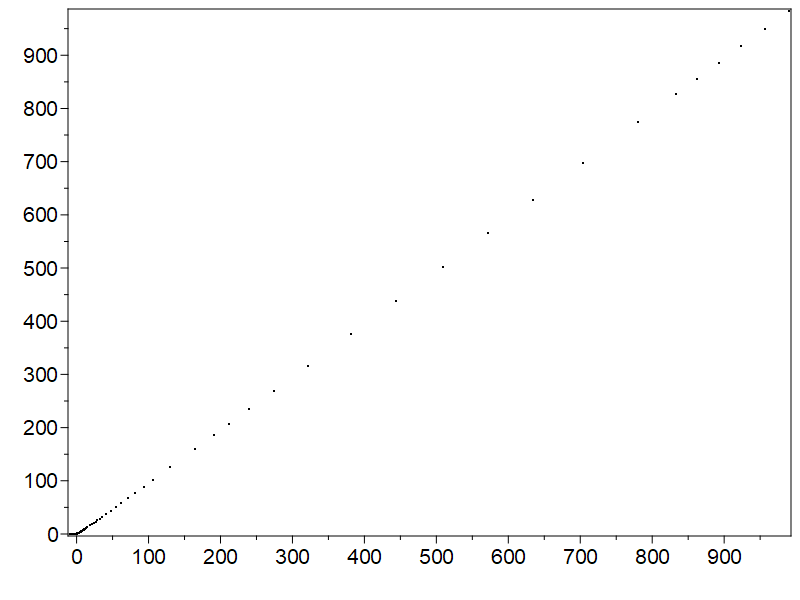

In [74]:
plot( xswi, yswi, style=point, symbol=point );

In [75]:
Digits := 15:
nrows := nout:
ncols := floor( nw/2 ) + 1: # 0 1.0e-12 , 1 1.0e-13, 2 5.0e-14
A := Matrix(nrows,ncols, (i,j)->(yswi[i]-phiw[j])/(xswi[i]-zzw[j])):

In [76]:
(U,S,Vt) := LinearAlgebra:-SingularValues(A, output=['U','S','Vt']):

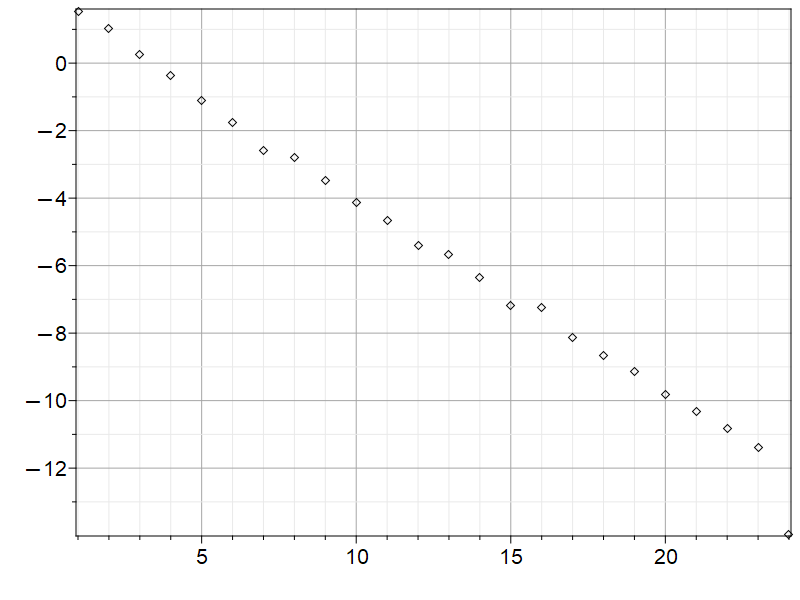

In [77]:
plot( [seq([k,log10(S[k])],k=1..ncols)], style=point, gridlines );

In [78]:
CMPL := proc( p::{list,Vector}, tau::{list,Vector}, gam::{list,Vector}, $ )
   local C0, C1, n, i, j, k, d;
   n := numelems(tau);

   d := n - 1;

   C1 := Matrix( d+2, d+2, (i,j)->`if`(i<>j,0,`if`(i=1,0,1)) );
   C0 := Matrix( d+2, d+2, 0 );
   k := 0;
   for i from 1 to n do
     C0[i+1,i+1]   :=  tau[i];
     C0[i+1,1]     := -gam[i];
     C0[1,i+1]     :=  p[i];
   end do;
   return C0, C1
end proc:

In [79]:
ncols, nw;

$$24$$,$$47$$

In [80]:
barywts := [seq(Vt[ncols,j],j=1..ncols)];

| | | | | | | | | | | | | | | | | | | | | | | | |
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|-.0196978588517238|.0124401767243302|-.0856729492251155|.0383862946453137|-.117123788255285|-.105875267113692|.165821223275091|-.103029874765885|.347692358843145|.0993819771458805|.0746933497558067|.0835590335897086|.0486626151754411|-.030821385233021|.0541425960176745|.0601858262082091|-.103828456860029|.507058903896597|-.0512189804787011|-.175783718057101|-.0532347776331409|-.669422172752633|-.0924454080122202|.116130281838698|


In [81]:
Digits := 15:
(C0z,C1z) := CMPL( phiw[1..ncols], zzw[1..ncols], barywts );

In [82]:
zeroest := LinearAlgebra:-Eigenvalues( C0z, C1z ):
finitezeros := select(t->type(t,complex(numeric)), convert(zeroest,list)):
"Zeros", latex( evalf[7]( finitezeros ));

[- 3172.211+ 0.0 \mathrm{I} , - 997.8995+ 0.0 \mathrm{I} , - 412.0895+ 0.0 \mathrm{I} , - 185.8936+ 0.0 \mathrm{I} , - 83.72003+ 0.0 \mathrm{I} , - 11.49294+ 0.7863922 \,\mathrm{I}, - 11.49294- 0.7863922 \,\mathrm{I}, - 10.91928+ 2.319170 \,\mathrm{I}, - 10.91928- 2.319170 \,\mathrm{I}, - 9.781314+ 3.713115 \,\mathrm{I}, - 9.781314- 3.713115 \,\mathrm{I}, - 8.112023+ 4.813441 \,\mathrm{I}, - 8.112023- 4.813441 \,\mathrm{I}, - 6.041292+ 5.383522 \,\mathrm{I}, - 6.041292- 5.383522 \,\mathrm{I}, - 3.960210+ 5.208138 \,\mathrm{I}, - 3.960210- 5.208138 \,\mathrm{I}, - 2.427210+ 4.492590 \,\mathrm{I}, - 2.427210- 4.492590 \,\mathrm{I}, - 1.126866+ 3.299836 \,\mathrm{I}, - 1.126866- 3.299836 \,\mathrm{I}, - 1.553006+ 3.768739 \,\mathrm{I}, - 1.553006- 3.768739 \,\mathrm{I}]

"Zeros"

In [83]:
numelems(finitezeros);

$$23$$

In [84]:
Digits := 15:
(C0p,C1p) := CMPL( [seq(1.0,j=1..ncols)], zzw[1..ncols], barywts ):

In [85]:
polest := LinearAlgebra:-Eigenvalues( C0p, C1p ):
finitepoles := select(t->type(t,complex(numeric)), convert(polest,list)):
"Poles", latex( evalf[7](finitepoles ));

[{ 2.678425\times 10^{8}}+ 0.0 \mathrm{I} , - 3173.654+ 0.0 \mathrm{I} , - 998.8642+ 0.0 \mathrm{I} , - 412.9022+ 0.0 \mathrm{I} , - 186.6563+ 0.0 \mathrm{I} , - 84.51997+ 0.0 \mathrm{I} , - 26.53847+ 0.0 \mathrm{I} , - 17.73974+ 10.40926 \,\mathrm{I}, - 17.73974- 10.40926 \,\mathrm{I}, - 10.40508+ 11.03645 \,\mathrm{I}, - 10.40508- 11.03645 \,\mathrm{I}, - 6.100728+ 9.415436 \,\mathrm{I}, - 6.100728- 9.415436 \,\mathrm{I}, - 3.678339+ 7.506277 \,\mathrm{I}, - 3.678339- 7.506277 \,\mathrm{I}, - 2.342373+ 5.861356 \,\mathrm{I}, - 2.342373- 5.861356 \,\mathrm{I}, - 1.621132+ 4.621292 \,\mathrm{I}, - 1.621132- 4.621292 \,\mathrm{I}, - 1.239899+ 3.780751 \,\mathrm{I}, - 1.239899- 3.780751 \,\mathrm{I}, - 1.055141+ 3.298436 \,\mathrm{I}, - 1.055141- 3.298436 \,\mathrm{I}]

"Poles"

In [86]:
numelems(finitepoles);

$$23$$

In [87]:
tb := x -> mul( x-zz, zz in finitezeros)/mul( x-pp, pp in finitepoles ):

In [88]:
K := Wrightomega(1.0)/tb(1.0);

$$- 2.67810945026534557\times 10^{8}- 1.72695531487576913\times 10^{-8} \mathrm{I}$$

In [89]:
FactoredTCFomega := x -> K*tb(x);

x -> K*tb(x)

kilobytes used=129374, alloc=27097, time=13.92

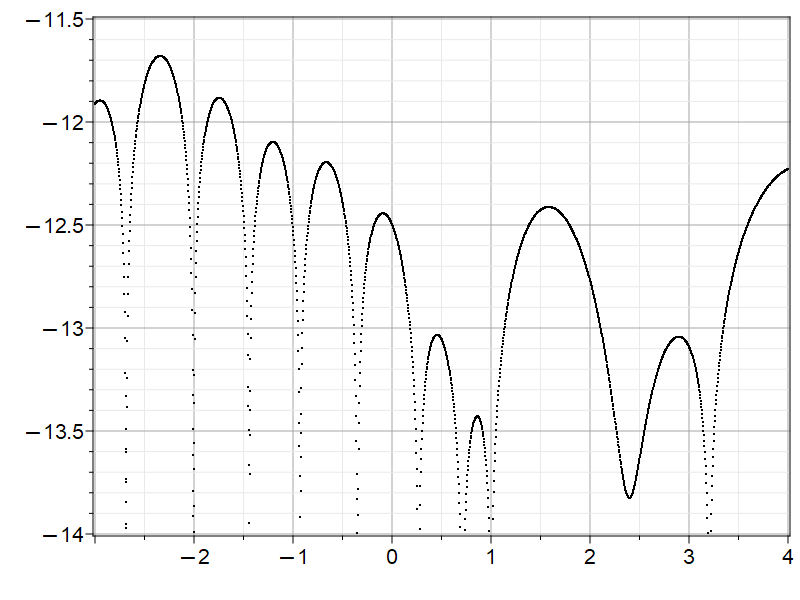

In [90]:
Digits := 30;
plot( x->log10(abs(FactoredTCFomega(x)-Wrightomega(x))), -3..4, 
  style=point, symbol=point, numpoints=2026, gridlines);

In [91]:
Digits := 30:
poleset := convert(finitepoles,set):
resfn := p -> K*mul(p-zz, zz in finitezeros)/mul( p-pp, pp in poleset minus {p}):

In [92]:
latex( evalf[7]([map( p->[p,resfn(p)], finitepoles )]) );

[[[{ 2.678425\times 10^{8}}+ 0.0 \mathrm{I} , - 7.173112\times 10^{16}+ 179.2061 \,\mathrm{I}], [- 3173.654+ 0.0 \mathrm{I} ,  4590.629- 1.933389\times 10^{-7} \mathrm{I}], [- 998.8642+ 0.0 \mathrm{I} ,  969.9320+ 1.037172\times 10^{-6} \mathrm{I}], [- 412.9022+ 0.0 \mathrm{I} ,  340.1918- 4.966562\times 10^{-6} \mathrm{I}], [- 186.6563+ 0.0 \mathrm{I} ,  146.0992- 8.713859\times 10^{-7} \mathrm{I}], [- 84.51997+ 0.0 \mathrm{I} ,  70.84428+ 1.102131\times 10^{-6} \mathrm{I}], [- 26.53847+ 0.0 \mathrm{I} ,  100.4991+ 0.00002431351 \,\mathrm{I}], [- 17.73974+ 10.40926 \,\mathrm{I}, - 0.1080999- 34.36826 \,\mathrm{I}], [- 17.73974- 10.40926 \,\mathrm{I}, - 0.1081001+ 34.36826 \,\mathrm{I}], [- 10.40508+ 11.03645 \,\mathrm{I}, - 9.752760- 10.35628 \,\mathrm{I}], [- 10.40508- 11.03645 \,\mathrm{I}, - 9.752765+ 10.35629 \,\mathrm{I}], [- 6.100728+ 9.415436 \,\mathrm{I}, - 6.135672- 2.192255 \,\mathrm{I}], [- 6.100728- 9.415436 \,\mathrm{I}, - 6.135675+ 2.192256 \,\mathrm{I}], [- 3.678339+ 7.

## Pade approximant ##

In [93]:
Order := numelems(finitezeros)+numelems(finitepoles)+1;

$$47$$

In [94]:
ws := series(Wrightomega(1+x),x):

In [95]:
wpade := CodeTools:-Usage( convert(ws,ratpoly) ):

memory used=42.32MiB, alloc change=-8.00MiB, cpu time=718.00ms, real time=601.00ms, gc time=187.50ms

In [96]:
top := numer(wpade):
degree(top,x);

$$23$$

In [97]:
bot := denom(wpade):
degree(bot,x);

$$23$$

In [98]:
padezeros := fsolve(top,x,'complex'):
padepoles := fsolve(bot,x,'complex'):

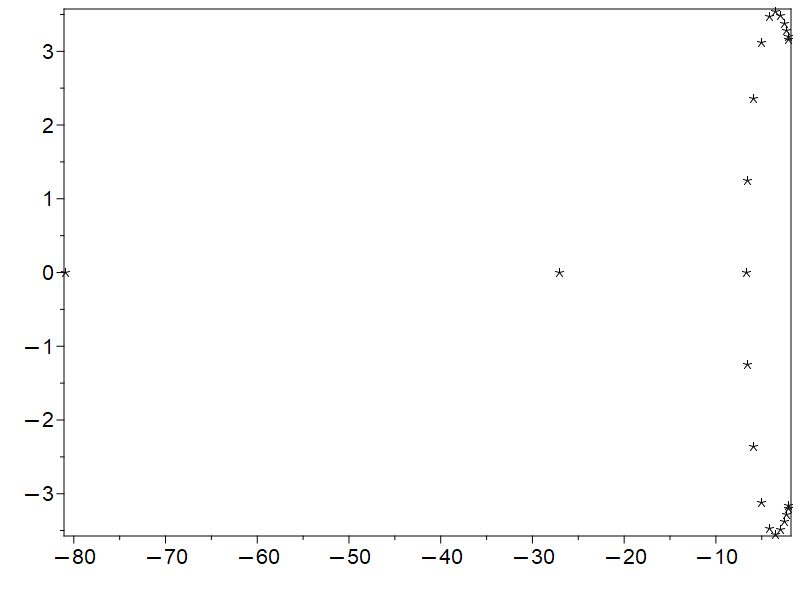

In [99]:
pzplot := plots[complexplot]([padezeros], style=point, symbol=asterisk);

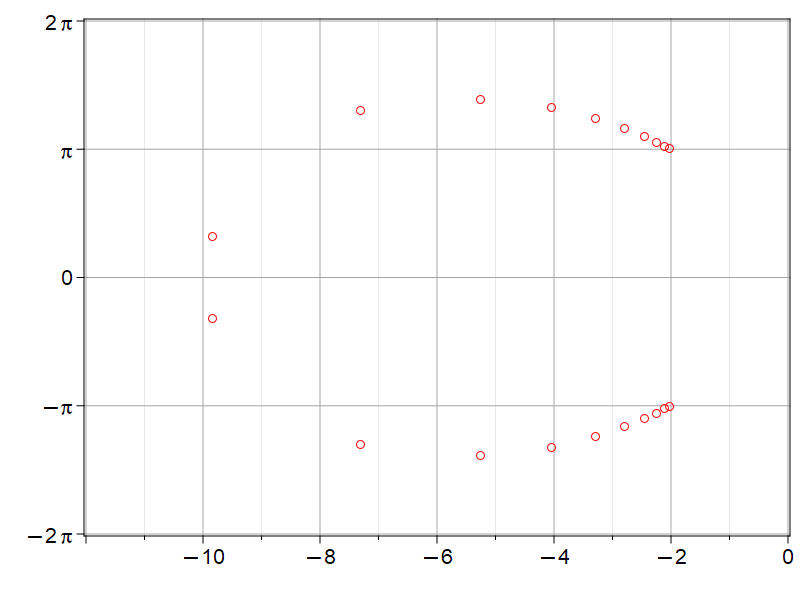

In [100]:
ppplot := plots[complexplot]([padepoles], style=point, symbol=circle, colour=red, 
                             view=[-12..0, -2*Pi..2*Pi], tickmarks=[default, spacing(Pi)], gridlines);

kilobytes used=162380, alloc=26072, time=16.72

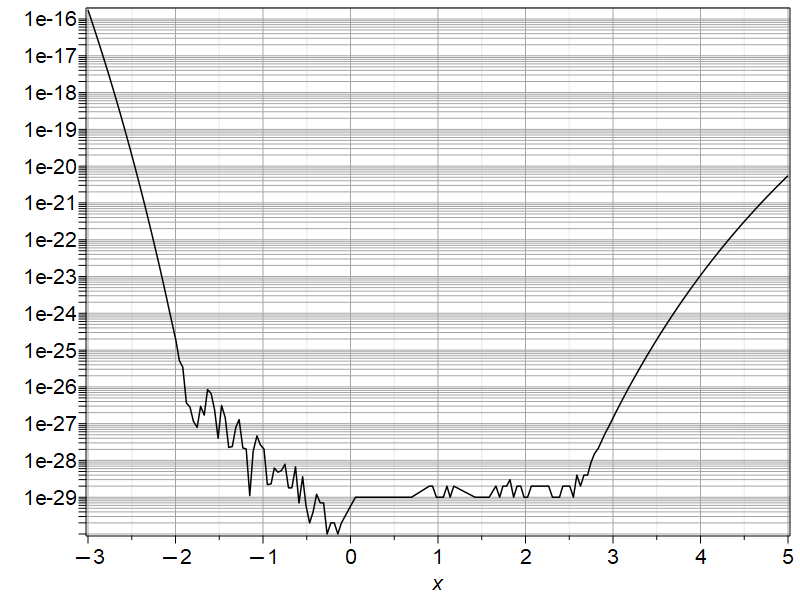

In [101]:
Digits := 30:
plots[logplot](abs( wpade-Wrightomega(1+x) ), x=-3..5, view=[-3..5, default] , gridlines);

In [102]:
evalf[7]( convert(wpade,confrac,x) );

kilobytes used=272664, alloc=29162, time=23.30

$$- 157376.2-\frac{ 2.488483\times 10^{10}}{x - 158127.4+\frac{ 160.5724}{x + 64.30071-\frac{ 827.9817}{x + 33.63747-\frac{ 144.1489}{x + 17.99421-\frac{ 26.82331}{x + 10.70861+\frac{ 12.72636}{x + 5.397255-\frac{ 31.56471}{x + 4.210075+\frac{ 41.11561}{x + 7.310050+\frac{ 2.903680}{x + 17.70627+\frac{ 163.5479}{x - 7.338459+\frac{ 5.284352}{x + 9.550790+\frac{ 9.564456}{x + 7.696733+\frac{ 47.49996}{x - 2.480415-\frac{ 1.003193}{x - 1.258395+\frac{ 34.91192}{x + 7.020694+\frac{ 0.6827783}{x + 4.583389+\frac{ 18.74038}{x + 0.5970076-\frac{ 0.05805620}{x - 25.60803+\frac{ 793.5370}{x + 30.26190+\frac{ 0.02387931}{x + 1.325770+\frac{ 12.43266}{x + 3.068388+\frac{ 0.02834624}{x + 6.184465+\frac{ 27.48435}{x - 2.045225}}}}}}}}}}}}}}}}}}}}}}}$$